# Analyse et Ingénierie des Données de la Chlordécone aux Antilles françaises

**Auteur :** Younes — ENSAR A1 SD  
**Date :** Mars 2026  
**Cours :** Ingénierie des données avec Python et RStudio — S. Manou-Abi  

---

## Sommaire

### VOLET 1 — Ingénierie des Données
1. Import et exploration initiale
2. Manipulation de données tabulaires (group_by, filter, mutate, summarise)
3. Recodage et transformation
4. Jointure de données
5. Contrôle et flux de données (boucles, conditions, apply)
6. Transformation et exploration (dates, text mining, variables)
7. Valeurs manquantes et data cleaning
8. Données spécifiques (texte, spatiales)

### VOLET 2 — Analyse de Données
9. Analyse exploratoire (statistiques descriptives, visualisations)
10. ACP (Analyse en Composantes Principales)
11. AFC (Analyse Factorielle des Correspondances)
12. Clustering (K-means, CAH)
13. KNN et classification
14. Tests statistiques et inférence
15. Aide à la décision — Synthèse et recommandations


---
# VOLET 1 — Ingénierie des Données
---

## 1. Import et exploration initiale


In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.stats import chi2_contingency, f_oneway, pearsonr, spearmanr
import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12
sns.set_style("whitegrid")
sns.set_palette("viridis")

print("Bibliothèques importées avec succès")


Bibliothèques importées avec succès


In [65]:
# Chargement des données
df = pd.read_csv("../data/BaseCLD2026.csv", sep=";", encoding="latin-1")

print("Dimensions du dataset :", df.shape[0], "lignes x", df.shape[1], "colonnes")
print()
print("Colonnes :")
for i, col in enumerate(df.columns, 1):
    print("  {:2d}. {}".format(i, col))


Dimensions du dataset : 31126 lignes x 22 colonnes

Colonnes :
   1. ID
   2. ANNEE
   3. COMMU_LAB
   4. RAIN
   5. Sol_simple
   6. type_sol
   7. Date_prelevement
   8. Date_enregistrement
   9. Date_analyse
  10. Operateur_chld
  11. Taux_Chlordecone
  12. Operateur_5b
  13. Taux_5b_hydro
  14. histoBanane_Histo_ban
  15. mnt_tpi_mean
  16. mnt_tri_mean
  17. mnt_rugosite_mean
  18. mnt_ombrage_mean
  19. mnt_exposition_mean
  20. mnt_pente_mean
  21. X
  22. Y


In [66]:
# Aperçu des premières lignes
df.head(10)


,ID,ANNEE,COMMU_LAB,RAIN,Sol_simple,type_sol,Date_prelevement,Date_enregistrement,Date_analyse,Operateur_chld,...,Taux_5b_hydro,histoBanane_Histo_ban,mnt_tpi_mean,mnt_tri_mean,mnt_rugosite_mean,mnt_ombrage_mean,mnt_exposition_mean,mnt_pente_mean,X,Y
0,20143,2010,GROS-MORNE,2000-3000,Andosol,Intergrades Sols â¦ allophane relativement â...,24/05/2007,24/05/2007,24/05/2007,=,...,"0,07",2.0,5.805967,8.033367,21.593658,131.173998,79.447954,39.043098,714300.831892,1.626344e+06
1,20143,2010,GROS-MORNE,2000-3000,Andosol,Intergrades Sols â¦ allophane relativement â...,24/05/2007,24/05/2007,24/05/2007,=,...,"0,07",2.0,5.683589,7.920563,20.944901,134.608205,76.985690,38.123675,714303.743345,1.626354e+06
2,20143,2010,GROS-MORNE,2000-3000,Andosol,Intergrades Sols â¦ allophane relativement â...,24/05/2007,24/05/2007,24/05/2007,=,...,"0,07",3.0,2.239457,7.108432,20.085883,139.420523,76.064719,34.976678,714309.446765,1.626360e+06
3,20143,2010,GROS-MORNE,2000-3000,Andosol,Intergrades Sols â¦ allophane relativement â...,24/05/2007,24/05/2007,24/05/2007,=,...,"0,07",1.0,4.038373,7.530090,23.427731,121.603678,92.392454,38.315796,714294.208512,1.626321e+06
4,20143,2010,GROS-MORNE,2000-3000,Andosol,Intergrades Sols â¦ allophane relativement â...,24/05/2007,24/05/2007,24/05/2007,=,...,"0,07",2.0,0.596502,6.637082,20.153770,134.065066,83.930611,33.877727,714303.823058,1.626341e+06
5,20143,2010,GROS-MORNE,2000-3000,Andosol,Intergrades Sols â¦ allophane relativement â...,24/05/2007,24/05/2007,24/05/2007,=,...,"0,07",3.0,6.000000,8.000000,21.000000,134.000000,77.228760,38.451267,714308.093485,1.626359e+06
6,20143,2010,GROS-MORNE,2000-3000,Andosol,Intergrades Sols â¦ allophane relativement â...,24/05/2007,24/05/2007,24/05/2007,=,...,"0,07",2.0,-4.936230,5.507017,16.611929,141.675174,80.476514,29.491132,714325.596772,1.626348e+06
7,20462,2010,DUCOS,1500-2000,Ferralsol,Ferrisols compacts,23/11/2009,23/11/2009,23/11/2009,<,...,inf,1.0,-1.502517,2.043345,4.918345,194.510068,320.787824,8.396590,719199.795165,1.609606e+06
8,21513,2012,SAINTE-MARIE,2000-3000,Nitisol,Sols bruns-rouille â¦ halloysite,08/11/2012,08/11/2012,25/03/2013,<,...,"0,015",1.0,1.008237,2.761811,9.167432,157.619371,103.324025,13.917334,714409.689460,1.634403e+06
9,21513,2012,SAINTE-MARIE,2000-3000,Nitisol,Sols bruns-rouille â¦ halloysite,08/11/2012,08/11/2012,25/03/2013,<,...,"0,015",1.0,2.645555,4.011851,11.721481,147.440003,124.606221,18.475084,714407.095536,1.634389e+06


In [67]:
# Types de données
print("Types de données :")
print(df.dtypes)
print()
print("Mémoire utilisée : {:.2f} Mo".format(df.memory_usage(deep=True).sum() / 1024**2))


Types de données :
ID                         int64
ANNEE                      int64
COMMU_LAB                 object
RAIN                      object
Sol_simple                object
type_sol                  object
Date_prelevement          object
Date_enregistrement       object
Date_analyse              object
Operateur_chld            object
Taux_Chlordecone         float64
Operateur_5b              object
Taux_5b_hydro             object
histoBanane_Histo_ban    float64
mnt_tpi_mean             float64
mnt_tri_mean             float64
mnt_rugosite_mean        float64
mnt_ombrage_mean         float64
mnt_exposition_mean      float64
mnt_pente_mean           float64
X                        float64
Y                        float64
dtype: object

Mémoire utilisée : 20.50 Mo


In [68]:
# Statistiques descriptives globales
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,31126.0,NaN,NaN,NaN,38451.270449,19380.547105,20003.0,21868.0,23412.0,62783.75,63714.0
ANNEE,31126.0,NaN,NaN,NaN,2015.318994,2.816359,2010.0,2013.0,2016.0,2018.0,2019.0
COMMU_LAB,30828,35,MORNE-ROUGE(LE),3725,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RAIN,31126,6,2000-3000,17425,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sol_simple,31052,7,Andosol,10953,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type_sol,28517,41,Sols â¦ allophane relativement peu âvoluâs,5794,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date_prelevement,31126,823,31/03/2017,442,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date_enregistrement,31126,854,05/11/2014,457,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date_analyse,31126,277,30/12/9999,2702,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Operateur_chld,31126,2,=,17533,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [69]:
# Informations sur le DataFrame
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31126 entries, 0 to 31125
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     31126 non-null  int64  
 1   ANNEE                  31126 non-null  int64  
 2   COMMU_LAB              30828 non-null  object 
 3   RAIN                   31126 non-null  object 
 4   Sol_simple             31052 non-null  object 
 5   type_sol               28517 non-null  object 
 6   Date_prelevement       31126 non-null  object 
 7   Date_enregistrement    31126 non-null  object 
 8   Date_analyse           31126 non-null  object 
 9   Operateur_chld         31126 non-null  object 
 10  Taux_Chlordecone       31126 non-null  float64
 11  Operateur_5b           31126 non-null  object 
 12  Taux_5b_hydro          31114 non-null  object 
 13  histoBanane_Histo_ban  13143 non-null  float64
 14  mnt_tpi_mean           31098 non-null  float64
 15  mn

## 2. Manipulation de données tabulaires

Démonstration des opérations `group_by`, `summarise`, `filter`, `mutate`, `order_by`  
Équivalent pandas des opérations dplyr de R.


In [70]:
# --- GROUP_BY + SUMMARISE ---
resume_commune = (
    df.groupby("COMMU_LAB")
    .agg(
        nb_parcelles=("ID", "count"),
        taux_moyen=("Taux_Chlordecone", "mean"),
        taux_median=("Taux_Chlordecone", "median"),
        taux_max=("Taux_Chlordecone", "max"),
        taux_std=("Taux_Chlordecone", "std")
    )
    .reset_index()
)
print("=== Résumé par commune (GROUP_BY + SUMMARISE) ===")
resume_commune.sort_values("taux_moyen", ascending=False).head(10)


=== Résumé par commune (GROUP_BY + SUMMARISE) ===


,COMMU_LAB,nb_parcelles,taux_moyen,taux_median,taux_max,taux_std
19,MORNE-ROUGE(LE),3725,2.800495,2.7580,17.350,2.808940
11,GRAND'RIVIERE,125,1.839945,0.3363,15.515,3.978387
16,MACOUBA,698,1.696628,1.5000,5.310,1.384085
2,BASSE-POINTE,992,1.381041,0.0900,9.300,2.245992
32,TRINITE(LA),1101,0.684156,0.0600,3.600,1.047650
17,MARIGOT(LE),475,0.613124,0.1250,2.000,0.799446
15,LORRAIN(LE),1763,0.583892,0.1850,12.779,1.430821
27,SAINT-PIERRE,339,0.561331,0.0053,4.131,1.132713
12,GROS-MORNE,2093,0.546698,0.0033,5.770,1.154055
14,LAMENTIN(LE),1930,0.442285,0.0033,5.672,1.085156


In [71]:
# --- FILTER ---
df_forte_contamination = df[df["Taux_Chlordecone"] > 1]
n_forte = len(df_forte_contamination)
pct_forte = n_forte / len(df) * 100
print("Parcelles fortement contaminées (>1 mg/kg) : {} ({:.1f}%)".format(n_forte, pct_forte))

# Filtrage multi-critères
df_filtre = df[
    (df["Taux_Chlordecone"] > 0.5) &
    (df["Sol_simple"] == "Andosol") &
    (df["ANNEE"] >= 2015)
]
print("Parcelles Andosol, >0.5 mg/kg, depuis 2015 :", len(df_filtre))


Parcelles fortement contaminées (>1 mg/kg) : 5560 (17.9%)
Parcelles Andosol, >0.5 mg/kg, depuis 2015 : 1320


In [72]:
# --- MUTATE (création de nouvelles colonnes) ---
df["classe_contamination"] = pd.cut(
    df["Taux_Chlordecone"],
    bins=[0, 0.01, 0.1, 1, 5, 20],
    labels=["Très faible", "Faible", "Modéré", "Élevé", "Très élevé"],
    include_lowest=True
)

# Log-transformation du taux
df["log_taux_cld"] = np.log1p(df["Taux_Chlordecone"])

# Indicateur de contamination détectée vs sous seuil
df["detection"] = np.where(df["Operateur_chld"] == "=", "Détecté", "Sous seuil (<)")

print("Nouvelles colonnes créées :")
print(df[["Taux_Chlordecone", "classe_contamination", "log_taux_cld", "detection"]].head(10))


Nouvelles colonnes créées :
   Taux_Chlordecone classe_contamination  log_taux_cld       detection
0            4.6000                Élevé      1.722767         Détecté
1            4.6000                Élevé      1.722767         Détecté
2            4.6000                Élevé      1.722767         Détecté
3            4.6000                Élevé      1.722767         Détecté
4            4.6000                Élevé      1.722767         Détecté
5            4.6000                Élevé      1.722767         Détecté
6            4.6000                Élevé      1.722767         Détecté
7            0.0033          Très faible      0.003295  Sous seuil (<)
8            0.0033          Très faible      0.003295  Sous seuil (<)
9            0.0033          Très faible      0.003295  Sous seuil (<)


In [73]:
# --- ORDER_BY (tri) ---
top15 = df.nlargest(15, "Taux_Chlordecone")[["ID", "COMMU_LAB", "ANNEE", "Taux_Chlordecone", "Sol_simple"]]
print("=== Top 15 parcelles les plus contaminées ===")
top15


=== Top 15 parcelles les plus contaminées ===


,ID,COMMU_LAB,ANNEE,Taux_Chlordecone,Sol_simple
7760,21120,MORNE-ROUGE(LE),2011,17.350,Andosol
7761,21120,MORNE-ROUGE(LE),2011,17.350,Andosol
7762,21120,MORNE-ROUGE(LE),2011,17.350,Andosol
7763,21120,MORNE-ROUGE(LE),2011,17.350,Andosol
7764,21120,MORNE-ROUGE(LE),2011,17.350,Andosol
7765,21120,MORNE-ROUGE(LE),2011,17.350,Andosol
7766,21120,MORNE-ROUGE(LE),2011,17.350,Andosol
7767,21120,MORNE-ROUGE(LE),2011,17.350,Andosol
21145,21120,MORNE-ROUGE(LE),2011,17.350,Andosol
21146,21120,MORNE-ROUGE(LE),2011,17.350,Andosol


In [74]:
# --- Détection d'incohérences ---
print("=== Détection d'incohérences dans les données ===")

# 1. Dates aberrantes (année 9999)
dates_aberrantes = df[df["Date_analyse"].str.contains("9999", na=False)]
print("1. Dates d'analyse aberrantes (année 9999) :", len(dates_aberrantes), "lignes")

# 2. Valeurs "inf" et "999" dans Taux_5b_hydro
nb_inf = df["Taux_5b_hydro"].astype(str).str.strip().isin(["inf"]).sum()
nb_999 = df["Taux_5b_hydro"].astype(str).str.strip().isin(["999"]).sum()
print("2. Taux_5b_hydro = inf :", nb_inf, "lignes")
print("   Taux_5b_hydro = 999 :", nb_999, "lignes")

# 3. Communes manquantes
print("3. Communes manquantes (NaN) :", df["COMMU_LAB"].isna().sum(), "lignes")

# 4. "Hors Martinique"
hors_mtq = df[df["COMMU_LAB"] == "Hors Martinique"]
print("4. Parcelles 'Hors Martinique' :", len(hors_mtq), "lignes")

# 5. Incohérence dates
df_dates_check = df.copy()
df_dates_check["dp"] = pd.to_datetime(df_dates_check["Date_prelevement"], format="%d/%m/%Y", errors="coerce")
df_dates_check["da"] = pd.to_datetime(df_dates_check["Date_analyse"], format="%d/%m/%Y", errors="coerce")
incoherence_dates = df_dates_check[df_dates_check["da"] < df_dates_check["dp"]]
print("5. Analyse avant prélèvement :", len(incoherence_dates), "lignes")

# 6. Taux négatifs
print("6. Taux chlordécone négatifs :", (df["Taux_Chlordecone"] < 0).sum(), "lignes")

# 7. Sol problématique
sol_problemes = df[df["Sol_simple"].isin(["No data", "Urban area"])]
print("7. Sol = No data ou Urban area :", len(sol_problemes), "lignes")


=== Détection d'incohérences dans les données ===
1. Dates d'analyse aberrantes (année 9999) : 2702 lignes
2. Taux_5b_hydro = inf : 586 lignes
   Taux_5b_hydro = 999 : 138 lignes
3. Communes manquantes (NaN) : 298 lignes
4. Parcelles 'Hors Martinique' : 27 lignes
5. Analyse avant prélèvement : 89 lignes
6. Taux chlordécone négatifs : 0 lignes
7. Sol = No data ou Urban area : 3329 lignes


In [75]:
# --- Modification, suppression et création de lignes ---

# Modification : nettoyer les noms de communes
df["commune_clean"] = df["COMMU_LAB"].str.replace(r"\(.*\)", "", regex=True).str.strip()
print("Communes nettoyées :")
print(df["commune_clean"].unique()[:10])

# Suppression de lignes
df_clean = df[df["COMMU_LAB"] != "Hors Martinique"].copy()
print("\nAvant suppression Hors Martinique :", len(df), "lignes")
print("Après suppression :", len(df_clean), "lignes")

# Indexation
print("\nValeur en ligne 0, col Taux_Chlordecone :", df.iloc[0]["Taux_Chlordecone"])
parcelle_id = 20143
communes_id = df.loc[df["ID"] == parcelle_id, "COMMU_LAB"].unique()
print("Parcelle ID {} — communes : {}".format(parcelle_id, communes_id))


Communes nettoyées :
['GROS-MORNE' 'DUCOS' 'SAINTE-MARIE' 'LORRAIN' 'ROBERT' 'VAUCLIN'
 'FRANCOIS' 'TRINITE' 'SAINT-PIERRE' 'FONDS-SAINT-DENIS']

Avant suppression Hors Martinique : 31126 lignes
Après suppression : 31099 lignes

Valeur en ligne 0, col Taux_Chlordecone : 4.6
Parcelle ID 20143 — communes : ['GROS-MORNE']


## 3. Recodage et transformation

Modifier et recoder des modalités, extraire des sous-ensembles, agréger.


In [76]:
# --- Recodage de modalités ---
rain_recode = {
    "0-1250": "Faible",
    "1250-1500": "Modérée",
    "1500-2000": "Modérée-haute",
    "2000-3000": "Haute",
    "3000-5000": "Très haute",
    "5000-8000": "Extrême"
}
df["RAIN_cat"] = df["RAIN"].map(rain_recode)
print("Recodage pluviométrie :")
print(df["RAIN_cat"].value_counts())

# Recoder histoBanane
histo_recode = {1.0: "Jamais banane", 2.0: "Banane passée", 3.0: "Banane actuelle"}
df["histo_banane_label"] = df["histoBanane_Histo_ban"].map(histo_recode)
print("\nHistorique bananier :")
print(df["histo_banane_label"].value_counts(dropna=False))


Recodage pluviométrie :
RAIN_cat
Haute            17425
Modérée-haute     7658
Très haute        4149
Modérée           1490
Faible             312
Extrême             92
Name: count, dtype: int64

Historique bananier :
histo_banane_label
NaN                17983
Jamais banane       6370
Banane passée       4697
Banane actuelle     2076
Name: count, dtype: int64


In [77]:
# --- Extraction de sous-ensembles ---
df_andosol = df[df["Sol_simple"] == "Andosol"]
print("Sous-ensemble Andosol :", len(df_andosol), "lignes")

df_recent = df[df["ANNEE"].between(2015, 2019)]
print("Sous-ensemble 2015-2019 :", len(df_recent), "lignes")

# --- Agrégation ---
agg_commune_sol = (
    df.groupby(["COMMU_LAB", "Sol_simple"])
    .agg(taux_moyen=("Taux_Chlordecone", "mean"), nb=("ID", "count"))
    .reset_index()
    .sort_values("taux_moyen", ascending=False)
)
print("\nAgrégation par commune x sol (Top 10) :")
agg_commune_sol.head(10)


Sous-ensemble Andosol : 10953 lignes
Sous-ensemble 2015-2019 : 21841 lignes

Agrégation par commune x sol (Top 10) :


,COMMU_LAB,Sol_simple,taux_moyen,nb
86,MORNE-ROUGE(LE),No data,2.868878,646
84,MORNE-ROUGE(LE),Andosol,2.818210,2999
50,GRAND'RIVIERE,Andosol,2.817162,39
8,BASSE-POINTE,No data,2.323042,144
71,MACOUBA,Andosol,1.893959,429
72,MACOUBA,No data,1.777906,201
51,GRAND'RIVIERE,No data,1.760729,56
87,MORNE-ROUGE(LE),Urban area,1.705475,72
7,BASSE-POINTE,Andosol,1.247024,799
149,TRINITE(LA),Nitisol,1.152933,172


## 4. Jointure de données

Démonstration de `left_join`, `right_join`, `inner_join`, `full_join` et analyse de leur impact.


In [78]:
# Création de DataFrames auxiliaires
communes_info = pd.DataFrame({
    "COMMU_LAB": ["GROS-MORNE", "DUCOS", "SAINTE-MARIE", "LORRAIN(LE)", "ROBERT(LE)",
                  "VAUCLIN(LE)", "FRANCOIS(LE)", "TRINITE(LA)", "SAINT-PIERRE",
                  "FONDS-SAINT-DENIS", "SAINT-JOSEPH", "RIVIERE-PILOTE",
                  "LAMENTIN(LE)", "MARIGOT(LE)", "RIVIERE-SALEE", "COMMUNE_FICTIVE"],
    "zone_geographique": ["Centre", "Sud", "Nord-Atlantique", "Nord-Atlantique", "Centre-Atlantique",
                          "Sud-Atlantique", "Centre-Atlantique", "Nord-Atlantique", "Nord-Caraïbe",
                          "Centre-intérieur", "Centre-intérieur", "Sud-Atlantique",
                          "Centre", "Nord-Atlantique", "Sud", "Nord"],
    "population_2020": [10200, 18500, 15800, 7200, 22300,
                        8100, 18600, 12800, 4100,
                        800, 16200, 12500,
                        40400, 3600, 13200, 999]
})

resume = df.groupby("COMMU_LAB").agg(
    taux_moyen=("Taux_Chlordecone", "mean"),
    nb_mesures=("ID", "count")
).reset_index()

print("Table principale (resume) :", len(resume), "communes")
print("Table secondaire (communes_info) :", len(communes_info), "communes")


Table principale (resume) : 35 communes
Table secondaire (communes_info) : 16 communes


In [79]:
# --- LEFT JOIN ---
left = pd.merge(resume, communes_info, on="COMMU_LAB", how="left")
print("LEFT JOIN : {} lignes (NaN zone_geo : {})".format(len(left), left["zone_geographique"].isna().sum()))

# --- RIGHT JOIN ---
right = pd.merge(resume, communes_info, on="COMMU_LAB", how="right")
print("RIGHT JOIN : {} lignes (NaN taux_moyen : {})".format(len(right), right["taux_moyen"].isna().sum()))

# --- INNER JOIN ---
inner = pd.merge(resume, communes_info, on="COMMU_LAB", how="inner")
print("INNER JOIN : {} lignes".format(len(inner)))

# --- FULL (OUTER) JOIN ---
full = pd.merge(resume, communes_info, on="COMMU_LAB", how="outer")
print("FULL JOIN : {} lignes".format(len(full)))


LEFT JOIN : 35 lignes (NaN zone_geo : 20)
RIGHT JOIN : 16 lignes (NaN taux_moyen : 1)
INNER JOIN : 15 lignes
FULL JOIN : 36 lignes


In [80]:
# --- Analyse de l'impact des jointures ---
print("=== Analyse comparative de l'impact des jointures ===")
print("{:<15} {:<10} {:<15} {:<15}".format("Type", "Lignes", "NaN gauche", "NaN droite"))
print("-" * 55)
for name, result in [("LEFT", left), ("RIGHT", right), ("INNER", inner), ("FULL", full)]:
    nan_left = result["taux_moyen"].isna().sum()
    nan_right = result["zone_geographique"].isna().sum()
    print("{:<15} {:<10} {:<15} {:<15}".format(name, len(result), nan_left, nan_right))

print()
print("Conclusion : le LEFT JOIN preserve toutes nos mesures sans perte de donnees.")
print("L'INNER JOIN est le plus restrictif, le FULL JOIN le plus inclusif.")


=== Analyse comparative de l'impact des jointures ===
Type            Lignes     NaN gauche      NaN droite     
-------------------------------------------------------
LEFT            35         0               20             
RIGHT           16         1               0              
INNER           15         0               0              
FULL            36         1               20             

Conclusion : le LEFT JOIN preserve toutes nos mesures sans perte de donnees.
L'INNER JOIN est le plus restrictif, le FULL JOIN le plus inclusif.


## 5. Contrôle et flux de données

Structures de contrôle, boucles, et fonctions apply.


In [81]:
# --- IF / ELSE ---
def classifier_risque(taux):
    if taux > 5:
        return "Critique"
    elif taux > 1:
        return "Élevé"
    elif taux > 0.1:
        return "Modéré"
    elif taux > 0.01:
        return "Faible"
    else:
        return "Négligeable"

df["niveau_risque"] = df["Taux_Chlordecone"].apply(classifier_risque)
print("Classification du risque (if/else) :")
print(df["niveau_risque"].value_counts())


Classification du risque (if/else) :
niveau_risque
Négligeable    16926
Modéré          5217
Élevé           4914
Faible          3423
Critique         646
Name: count, dtype: int64


In [82]:
# --- SWITCH (dictionnaire en Python) ---
sol_danger = {
    "Andosol": "Fort potentiel de rétention",
    "Ferralsol": "Rétention modérée",
    "Nitisol": "Rétention modérée-forte",
    "Vertisol": "Adsorption variable",
    "Alluvium, Colluvium": "Risque de lessivage",
    "No data": "Non évalué",
    "Urban area": "Zone urbaine"
}
df["comportement_sol"] = df["Sol_simple"].map(sol_danger).fillna("Inconnu")
print("Switch - comportement des sols :")
print(df["comportement_sol"].value_counts())


Switch - comportement des sols :
comportement_sol
Fort potentiel de rétention    10953
Adsorption variable             6921
Rétention modérée               5182
Rétention modérée-forte         3063
Non évalué                      2617
Risque de lessivage             1604
Zone urbaine                     712
Inconnu                           74
Name: count, dtype: int64


In [83]:
# --- BOUCLE FOR ---
print("Évolution du taux moyen par année (boucle for) :")
for annee in sorted(df["ANNEE"].unique()):
    subset = df[df["ANNEE"] == annee]
    moy = subset["Taux_Chlordecone"].mean()
    med = subset["Taux_Chlordecone"].median()
    print("  {} : moyenne={:.4f}, médiane={:.4f}, n={}".format(annee, moy, med, len(subset)))


Évolution du taux moyen par année (boucle for) :
  2010 : moyenne=2.7782, médiane=2.6500, n=3928
  2011 : moyenne=1.3894, médiane=0.1100, n=1163


  2012 : moyenne=0.4954, médiane=0.0200, n=1479
  2013 : moyenne=0.3682, médiane=0.0033, n=1562
  2014 : moyenne=0.3697, médiane=0.0800, n=1153
  2015 : moyenne=0.5204, médiane=0.0033, n=3158
  2016 : moyenne=0.2191, médiane=0.0033, n=4316
  2017 : moyenne=0.5291, médiane=0.0060, n=5141
  2018 : moyenne=0.1120, médiane=0.0020, n=8567
  2019 : moyenne=0.3805, médiane=0.1160, n=659


In [84]:
# --- BOUCLE WHILE ---
seuil = df["Taux_Chlordecone"].max()
target_pct = 0.10
step = 0.1

while (df["Taux_Chlordecone"] >= seuil).sum() / len(df) < target_pct:
    seuil -= step

pct_actual = (df["Taux_Chlordecone"] >= seuil).sum() / len(df) * 100
print("Seuil pour isoler ~10% des plus contaminées : {:.2f} mg/kg".format(seuil))
print("Proportion réelle : {:.1f}%".format(pct_actual))


Seuil pour isoler ~10% des plus contaminées : 2.55 mg/kg
Proportion réelle : 10.0%


In [85]:
# --- FONCTIONS APPLY (equivalents de lapply, sapply, apply) ---
cols_num = ["Taux_Chlordecone", "mnt_pente_mean", "mnt_exposition_mean", "mnt_rugosite_mean"]
print("apply - Statistiques par colonne :")
print(df[cols_num].apply(["mean", "std", "min", "max"]))

print()
print("map - Nombre de valeurs uniques par colonne :")
print(df.select_dtypes(include="object").apply(lambda x: x.nunique()))

print()
print("applymap - Les taux sont-ils > 1 ?")
print(df[["Taux_Chlordecone"]].head(5).map(lambda x: "OUI" if x > 1 else "non"))


apply - Statistiques par colonne :
      Taux_Chlordecone  mnt_pente_mean  mnt_exposition_mean  mnt_rugosite_mean
mean          0.667663       20.267107           170.170931          13.444068
std           1.559895       13.373907            95.738110           8.625712
min           0.001000        0.000000             0.000000           0.000000
max          17.350000      124.949989           359.144897          85.396165

map - Nombre de valeurs uniques par colonne :
COMMU_LAB               35
RAIN                     6
Sol_simple               7
type_sol                41
Date_prelevement       823
Date_enregistrement    854
Date_analyse           277
Operateur_chld           2
Operateur_5b             2
Taux_5b_hydro          155
detection                2
commune_clean           35
RAIN_cat                 6
histo_banane_label       3
niveau_risque            5
comportement_sol         8
dtype: int64

applymap - Les taux sont-ils > 1 ?
  Taux_Chlordecone
0              OUI
1   

In [86]:
# --- Recherche d'éléments spécifiques ---
parcelles_gm = df[df["COMMU_LAB"] == "GROS-MORNE"]
print("Parcelles à Gros-Morne :", len(parcelles_gm))

idx_max = df["Taux_Chlordecone"].idxmax()
row_max = df.loc[idx_max]
print()
print("Parcelle la plus contaminée :")
print("  ID={}, Commune={}, Taux={} mg/kg".format(
    row_max["ID"], row_max["COMMU_LAB"], row_max["Taux_Chlordecone"]))

result = df.query("Taux_Chlordecone > 10 and Sol_simple == 'Andosol'")
print()
print("Parcelles Andosol avec taux > 10 mg/kg :", len(result))


Parcelles à Gros-Morne : 2093

Parcelle la plus contaminée :
  ID=21120, Commune=MORNE-ROUGE(LE), Taux=17.35 mg/kg

Parcelles Andosol avec taux > 10 mg/kg : 98


## 6. Transformation et exploration

Dates, text mining, transformation de variables.


In [87]:
# --- GESTION DES DATES ---
df["Date_prelevement_dt"] = pd.to_datetime(df["Date_prelevement"], format="%d/%m/%Y", errors="coerce")
df["Date_enregistrement_dt"] = pd.to_datetime(df["Date_enregistrement"], format="%d/%m/%Y", errors="coerce")
df["Date_analyse_dt"] = pd.to_datetime(df["Date_analyse"], format="%d/%m/%Y", errors="coerce")

df["annee_prelevement"] = df["Date_prelevement_dt"].dt.year
df["mois_prelevement"] = df["Date_prelevement_dt"].dt.month
df["jour_semaine"] = df["Date_prelevement_dt"].dt.day_name()
df["trimestre"] = df["Date_prelevement_dt"].dt.quarter
df["saison"] = df["mois_prelevement"].map({
    1: "Carême", 2: "Carême", 3: "Carême", 4: "Carême",
    5: "Transition", 6: "Hivernage", 7: "Hivernage",
    8: "Hivernage", 9: "Hivernage", 10: "Hivernage",
    11: "Transition", 12: "Carême"
})

print("Extraction temporelle :")
print(df[["Date_prelevement", "annee_prelevement", "mois_prelevement", "trimestre", "saison"]].head(10))

# Calcul du délai
df["delai_analyse_jours"] = (df["Date_analyse_dt"] - df["Date_prelevement_dt"]).dt.days
delais_valides = df["delai_analyse_jours"][(df["delai_analyse_jours"] > 0) & (df["delai_analyse_jours"] < 3650)]
print()
print("Délai moyen prélèvement -> analyse : {:.0f} jours".format(delais_valides.mean()))
print("Délai médian : {:.0f} jours".format(delais_valides.median()))


Extraction temporelle :
  Date_prelevement  annee_prelevement  mois_prelevement  trimestre      saison
0       24/05/2007               2007                 5          2  Transition
1       24/05/2007               2007                 5          2  Transition
2       24/05/2007               2007                 5          2  Transition
3       24/05/2007               2007                 5          2  Transition
4       24/05/2007               2007                 5          2  Transition
5       24/05/2007               2007                 5          2  Transition
6       24/05/2007               2007                 5          2  Transition
7       23/11/2009               2009                11          4  Transition
8       08/11/2012               2012                11          4  Transition
9       08/11/2012               2012                11          4  Transition

Délai moyen prélèvement -> analyse : 111 jours
Délai médian : 96 jours


In [88]:
# --- TEXT MINING sur type_sol ---
from collections import Counter
import re

all_words = []
for desc in df["type_sol"].dropna():
    words = re.findall(r"[a-zA-Zéèêàùâôîïü]+", str(desc).lower())
    all_words.extend(words)

word_freq = Counter(w for w in all_words if len(w) > 3)
top_words = word_freq.most_common(20)

print("=== Text Mining - Mots les plus fréquents dans type_sol ===")
for word, freq in top_words:
    print("  {:<25} : {:>5}".format(word, freq))

df["sol_keyword"] = df["type_sol"].str.extract(r"(Ferrisols|Sols|Intergrades|Vertisols|allophane)", expand=False)
print("\nMot-clé sol extrait :")
print(df["sol_keyword"].value_counts())


=== Text Mining - Mots les plus fréquents dans type_sol ===
  sols                      : 19493
  voluâ                     : 11307
  allophane                 :  9457
  relativement              :  9457
  bruns                     :  7563
  ferrisols                 :  6670
  compacts                  :  6670
  rouges                    :  4244
  montmorillonitiques       :  4244
  rouille                   :  3319
  halloysite                :  3319
  vertisols                 :  2481
  intergrades               :  2360
  ustic                     :  2192
  cendres                   :  1850
  alluvions                 :  1300
  continentales             :  1231
  zones                     :   707
  urbanisâ                  :   707
  vertiques                 :   591

Mot-clé sol extrait :
sol_keyword
Sols           16736
Ferrisols       4790
Vertisols       2355
Intergrades     2328
Name: count, dtype: int64


In [89]:
# --- Transformation de variables ---

# Conversion de Taux_5b_hydro
df["Taux_5b_num"] = (
    df["Taux_5b_hydro"]
    .astype(str)
    .str.replace(",", ".", regex=False)
    .str.strip()
)
df["Taux_5b_num"] = df["Taux_5b_num"].replace(["inf", "999", "nan"], np.nan)
df["Taux_5b_num"] = pd.to_numeric(df["Taux_5b_num"], errors="coerce")

print("Taux_5b_hydro nettoyé :")
print(df["Taux_5b_num"].describe())
print("NaN après nettoyage :", df["Taux_5b_num"].isna().sum())

print()
print("Modalités de Sol_simple :")
print(df["Sol_simple"].value_counts(normalize=True).map(lambda x: "{:.1%}".format(x)))


Taux_5b_hydro nettoyé :
count    30379.000000
mean         0.017921
std          0.038547
min          0.000000
25%          0.001000
50%          0.003300
75%          0.015000
max          0.380000
Name: Taux_5b_num, dtype: float64
NaN après nettoyage : 747

Modalités de Sol_simple :
Sol_simple
Andosol                35.3%
Vertisol               22.3%
Ferralsol              16.7%
Nitisol                 9.9%
No data                 8.4%
Alluvium, Colluvium     5.2%
Urban area              2.3%
Name: proportion, dtype: object


## 7. Valeurs manquantes et Data Cleaning

Identification, visualisation, imputation et processus reproductible.


In [90]:
# --- Identification des valeurs manquantes ---
print("=== Bilan des valeurs manquantes ===")
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({"NaN": missing, "%": missing_pct}).sort_values("%", ascending=False)
missing_df[missing_df["NaN"] > 0]


=== Bilan des valeurs manquantes ===


,NaN,%
histoBanane_Histo_ban,17983,57.77
histo_banane_label,17983,57.77
sol_keyword,4917,15.80
delai_analyse_jours,2702,8.68
Date_analyse_dt,2702,8.68
type_sol,2609,8.38
Taux_5b_num,747,2.40
COMMU_LAB,298,0.96
commune_clean,298,0.96
Sol_simple,74,0.24


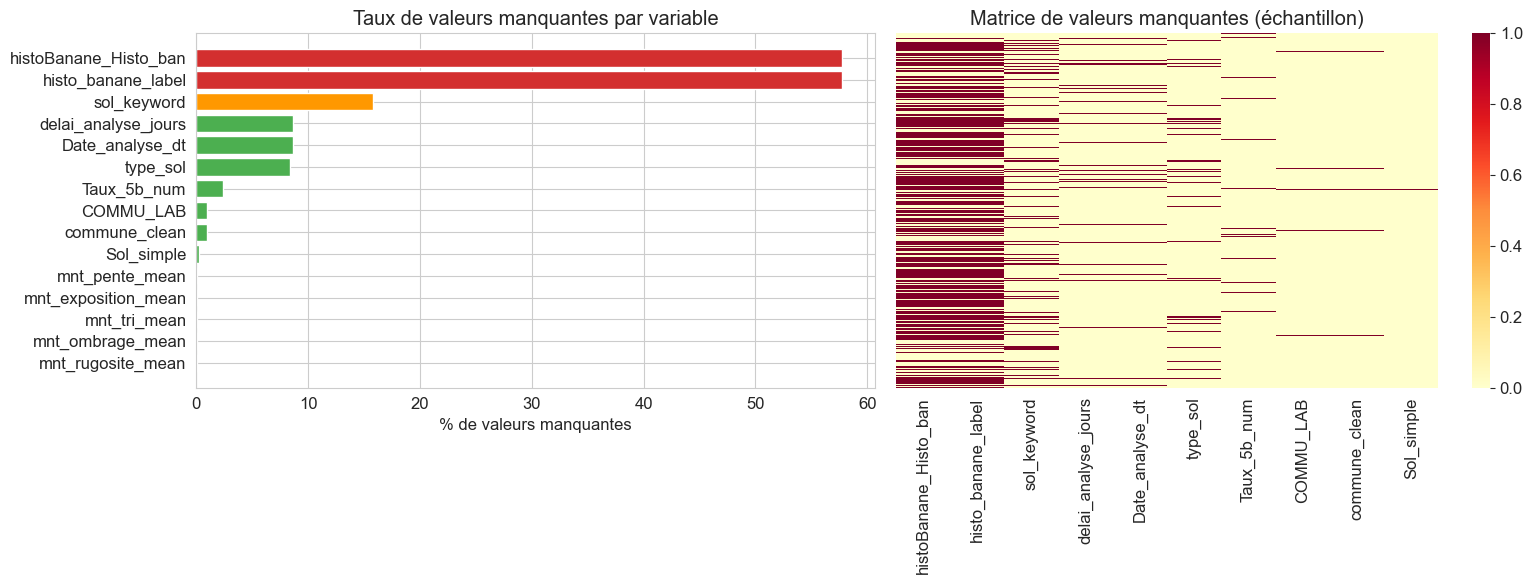

Figure sauvegardée : missing_values.png


In [91]:
# --- Visualisation des valeurs manquantes ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cols_with_na = missing_df[missing_df["NaN"] > 0].index.tolist()[:15]
vals = missing_df.loc[cols_with_na, "%"].values
colors_bar = ["#d32f2f" if v > 30 else "#ff9800" if v > 10 else "#4caf50" for v in vals]
axes[0].barh(cols_with_na, vals, color=colors_bar)
axes[0].set_xlabel("% de valeurs manquantes")
axes[0].set_title("Taux de valeurs manquantes par variable")
axes[0].invert_yaxis()

sample_cols = [c for c in cols_with_na if c in df.columns][:10]
sample = df[sample_cols].sample(min(500, len(df)), random_state=42)
sns.heatmap(sample.isnull(), cbar=True, cmap="YlOrRd", yticklabels=False, ax=axes[1])
axes[1].set_title("Matrice de valeurs manquantes (échantillon)")

plt.tight_layout()
plt.savefig("missing_values.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure sauvegardée : missing_values.png")


In [92]:
# --- Stratégies d'imputation ---

# 1. histoBanane (58% manquant) -> imputation par le mode par commune
df["histo_ban_imputed"] = df.groupby("COMMU_LAB")["histoBanane_Histo_ban"].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)
print("histoBanane - NaN avant :", df["histoBanane_Histo_ban"].isna().sum())
print("histoBanane - NaN après imputation par mode/commune :", df["histo_ban_imputed"].isna().sum())

# 2. type_sol -> imputation par Sol_simple
df["type_sol_imputed"] = df.groupby("Sol_simple")["type_sol"].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else "Inconnu")
)
print()
print("type_sol - NaN avant :", df["type_sol"].isna().sum())
print("type_sol - NaN après imputation :", df["type_sol_imputed"].isna().sum())

# 3. Variables MNT -> imputation par la médiane
mnt_cols = [c for c in df.columns if c.startswith("mnt_")]
for col in mnt_cols:
    df[col] = df[col].fillna(df[col].median())
print()
print("Variables MNT - NaN restants :", df[mnt_cols].isna().sum().sum())

# 4. COMMU_LAB -> imputation KNN spatiale
from sklearn.neighbors import NearestNeighbors
mask_no_commune = df["COMMU_LAB"].isna()
mask_has_commune = ~mask_no_commune

if mask_no_commune.sum() > 0:
    nn = NearestNeighbors(n_neighbors=1)
    nn.fit(df.loc[mask_has_commune, ["X", "Y"]])
    distances, indices = nn.kneighbors(df.loc[mask_no_commune, ["X", "Y"]])
    df.loc[mask_no_commune, "COMMU_LAB"] = df.loc[mask_has_commune, "COMMU_LAB"].iloc[indices.flatten()].values
    print()
    print("COMMU_LAB - NaN après imputation KNN spatiale :", df["COMMU_LAB"].isna().sum())


histoBanane - NaN avant : 17983
histoBanane - NaN après imputation par mode/commune : 1968

type_sol - NaN avant : 2609
type_sol - NaN après imputation : 74

Variables MNT - NaN restants : 0

COMMU_LAB - NaN après imputation KNN spatiale : 0


In [93]:
# --- Pipeline de Data Cleaning reproductible ---

def pipeline_nettoyage(df_raw):
    """
    Pipeline de nettoyage reproductible pour le dataset chlordécone.
    Entrée : DataFrame brut
    Sortie : DataFrame nettoyé
    """
    df = df_raw.copy()
    log = []
    
    # 1. Supprimer "Hors Martinique"
    n_before = len(df)
    df = df[df["COMMU_LAB"] != "Hors Martinique"]
    log.append("1. Suppression Hors Martinique : {} lignes retirées".format(n_before - len(df)))
    
    # 2. Corriger les dates aberrantes (9999)
    df["Date_analyse"] = df["Date_analyse"].replace("30/12/9999", np.nan)
    log.append("2. Dates 9999 remplacées par NaN")
    
    # 3. Convertir Taux_5b_hydro
    df["Taux_5b_hydro"] = (
        df["Taux_5b_hydro"].astype(str)
        .str.replace(",", ".", regex=False)
        .replace(["inf", "999", "nan"], np.nan)
    )
    df["Taux_5b_hydro"] = pd.to_numeric(df["Taux_5b_hydro"], errors="coerce")
    log.append("3. Taux_5b_hydro : virgules corrigées, inf/999 -> NaN")
    
    # 4. Convertir les dates
    for col in ["Date_prelevement", "Date_enregistrement", "Date_analyse"]:
        df[col] = pd.to_datetime(df[col], format="%d/%m/%Y", errors="coerce")
    log.append("4. Dates converties en datetime")
    
    # 5. Sol_simple = No data -> NaN
    df["Sol_simple"] = df["Sol_simple"].replace("No data", np.nan)
    log.append("5. Sol_simple : 'No data' -> NaN")
    
    # 6. Variables dérivées
    df["log_taux_cld"] = np.log1p(df["Taux_Chlordecone"])
    df["annee_prel"] = df["Date_prelevement"].dt.year
    df["mois_prel"] = df["Date_prelevement"].dt.month
    log.append("6. Variables dérivées créées")
    
    print("=== LOG DU PIPELINE DE NETTOYAGE ===")
    for l in log:
        print("  " + l)
    print()
    print("Dimensions finales :", df.shape)
    
    return df

# Appliquer le pipeline
df_raw = pd.read_csv("../data/BaseCLD2026.csv", sep=";", encoding="latin-1")
df_propre = pipeline_nettoyage(df_raw)
print()
print("Pipeline exécuté avec succès")


=== LOG DU PIPELINE DE NETTOYAGE ===
  1. Suppression Hors Martinique : 27 lignes retirées
  2. Dates 9999 remplacées par NaN
  3. Taux_5b_hydro : virgules corrigées, inf/999 -> NaN
  4. Dates converties en datetime
  5. Sol_simple : 'No data' -> NaN
  6. Variables dérivées créées

Dimensions finales : (31099, 25)

Pipeline exécuté avec succès


## 8. Données spécifiques — Texte et Spatial


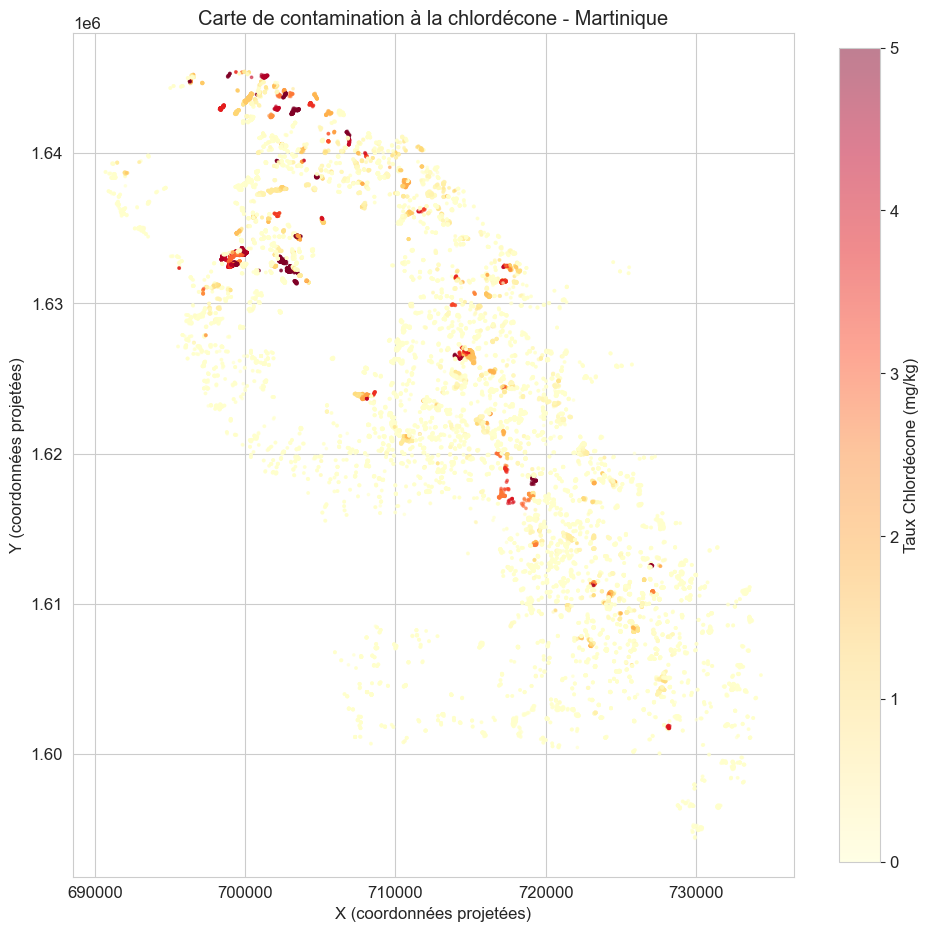

In [94]:
# --- Données spatiales ---
fig, ax = plt.subplots(1, 1, figsize=(10, 12))

scatter = ax.scatter(
    df["X"], df["Y"],
    c=df["Taux_Chlordecone"],
    cmap="YlOrRd",
    s=3, alpha=0.5,
    vmin=0, vmax=5
)
plt.colorbar(scatter, label="Taux Chlordécone (mg/kg)", shrink=0.7)
ax.set_xlabel("X (coordonnées projetées)")
ax.set_ylabel("Y (coordonnées projetées)")
ax.set_title("Carte de contamination à la chlordécone - Martinique")
ax.set_aspect("equal")
plt.tight_layout()
plt.savefig("carte_contamination.png", dpi=150, bbox_inches="tight")
plt.show()


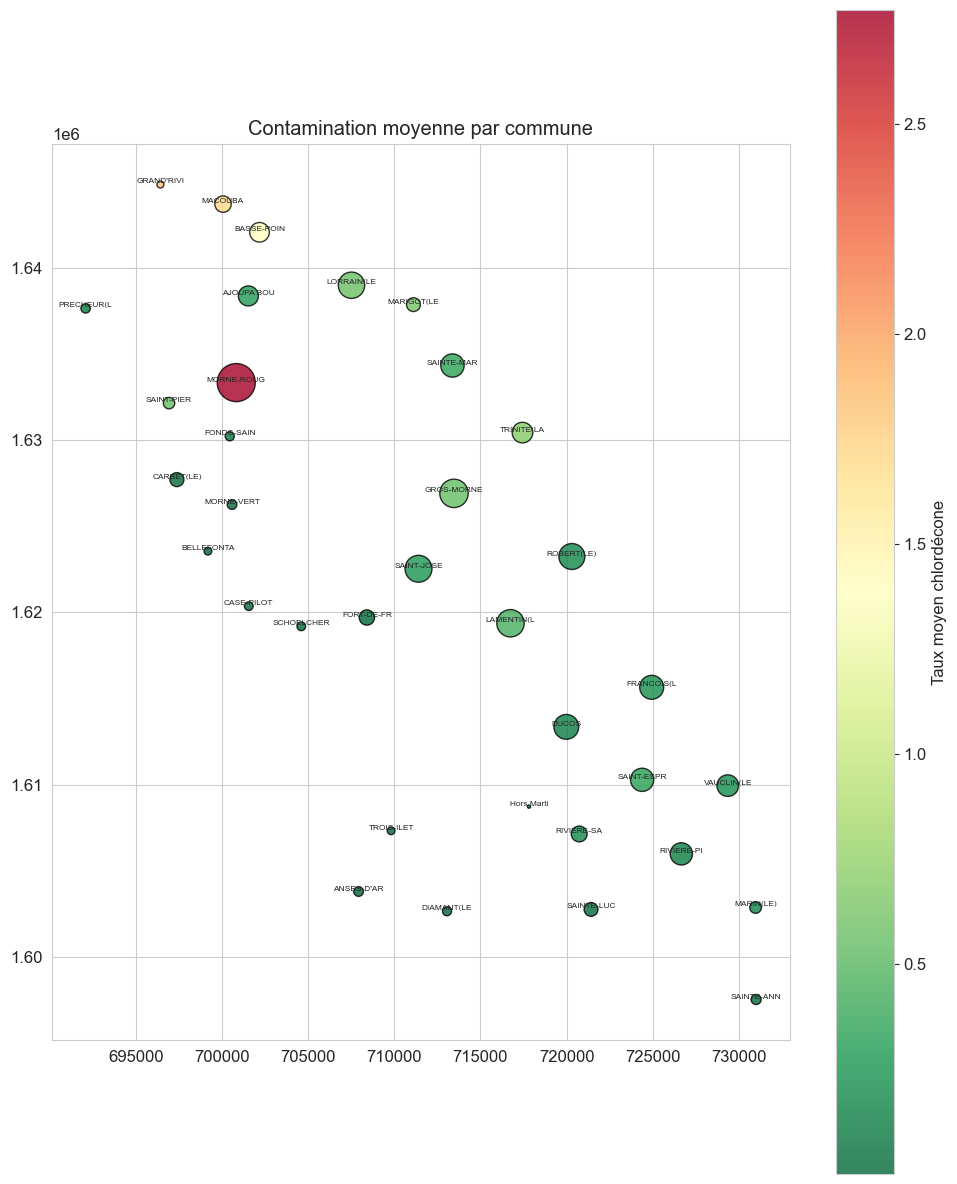

In [95]:
# --- Agrégation spatiale par commune ---
commune_spatial = df.groupby("COMMU_LAB").agg(
    X_moyen=("X", "mean"),
    Y_moyen=("Y", "mean"),
    taux_moyen=("Taux_Chlordecone", "mean"),
    nb_mesures=("ID", "count")
).reset_index()

fig, ax = plt.subplots(figsize=(10, 12))
scatter = ax.scatter(
    commune_spatial["X_moyen"], commune_spatial["Y_moyen"],
    c=commune_spatial["taux_moyen"],
    s=commune_spatial["nb_mesures"] / 5,
    cmap="RdYlGn_r",
    edgecolors="black", alpha=0.8
)
for _, row in commune_spatial.iterrows():
    ax.annotate(str(row["COMMU_LAB"])[:10], (row["X_moyen"], row["Y_moyen"]),
                fontsize=6, ha="center", va="bottom")
plt.colorbar(scatter, label="Taux moyen chlordécone")
ax.set_title("Contamination moyenne par commune")
ax.set_aspect("equal")
plt.tight_layout()
plt.savefig("carte_communes.png", dpi=150, bbox_inches="tight")
plt.show()


---
# VOLET 2 — Analyse de Données
---


## 9. Analyse exploratoire

Statistiques descriptives et visualisations adaptées.


In [96]:
# --- Statistiques descriptives ---
taux = df["Taux_Chlordecone"]
print("=== STATISTIQUES DESCRIPTIVES DU TAUX DE CHLORDÉCONE ===")
print("  Moyenne     : {:.4f} mg/kg".format(taux.mean()))
print("  Médiane     : {:.4f} mg/kg".format(taux.median()))
print("  Écart-type  : {:.4f} mg/kg".format(taux.std()))
print("  Min         : {:.4f} mg/kg".format(taux.min()))
print("  Max         : {:.4f} mg/kg".format(taux.max()))
print("  Q1          : {:.4f} mg/kg".format(taux.quantile(0.25)))
print("  Q3          : {:.4f} mg/kg".format(taux.quantile(0.75)))
print("  IQR         : {:.4f} mg/kg".format(taux.quantile(0.75) - taux.quantile(0.25)))
print("  Skewness    : {:.2f} (forte asymétrie droite)".format(taux.skew()))
print("  Kurtosis    : {:.2f}".format(taux.kurtosis()))
print()
print("=== TAUX MOYEN PAR TYPE DE SOL ===")
print(df.groupby("Sol_simple")["Taux_Chlordecone"].agg(["mean", "median", "std", "count"]).sort_values("mean", ascending=False))


=== STATISTIQUES DESCRIPTIVES DU TAUX DE CHLORDÉCONE ===
  Moyenne     : 0.6677 mg/kg
  Médiane     : 0.0033 mg/kg
  Écart-type  : 1.5599 mg/kg
  Min         : 0.0010 mg/kg
  Max         : 17.3500 mg/kg
  Q1          : 0.0024 mg/kg
  Q3          : 0.4100 mg/kg
  IQR         : 0.4076 mg/kg
  Skewness    : 3.70 (forte asymétrie droite)
  Kurtosis    : 18.58

=== TAUX MOYEN PAR TYPE DE SOL ===
                         mean  median       std  count
Sol_simple                                            
Andosol              1.242087  0.0900  2.093729  10953
No data              1.151744  0.0200  2.091671   2617
Alluvium, Colluvium  0.411256  0.0570  0.793528   1604
Nitisol              0.319736  0.0033  0.918473   3063
Urban area           0.312737  0.0033  1.047746    712
Ferralsol            0.208103  0.0033  0.648313   5182
Vertisol             0.163543  0.0033  0.528307   6921


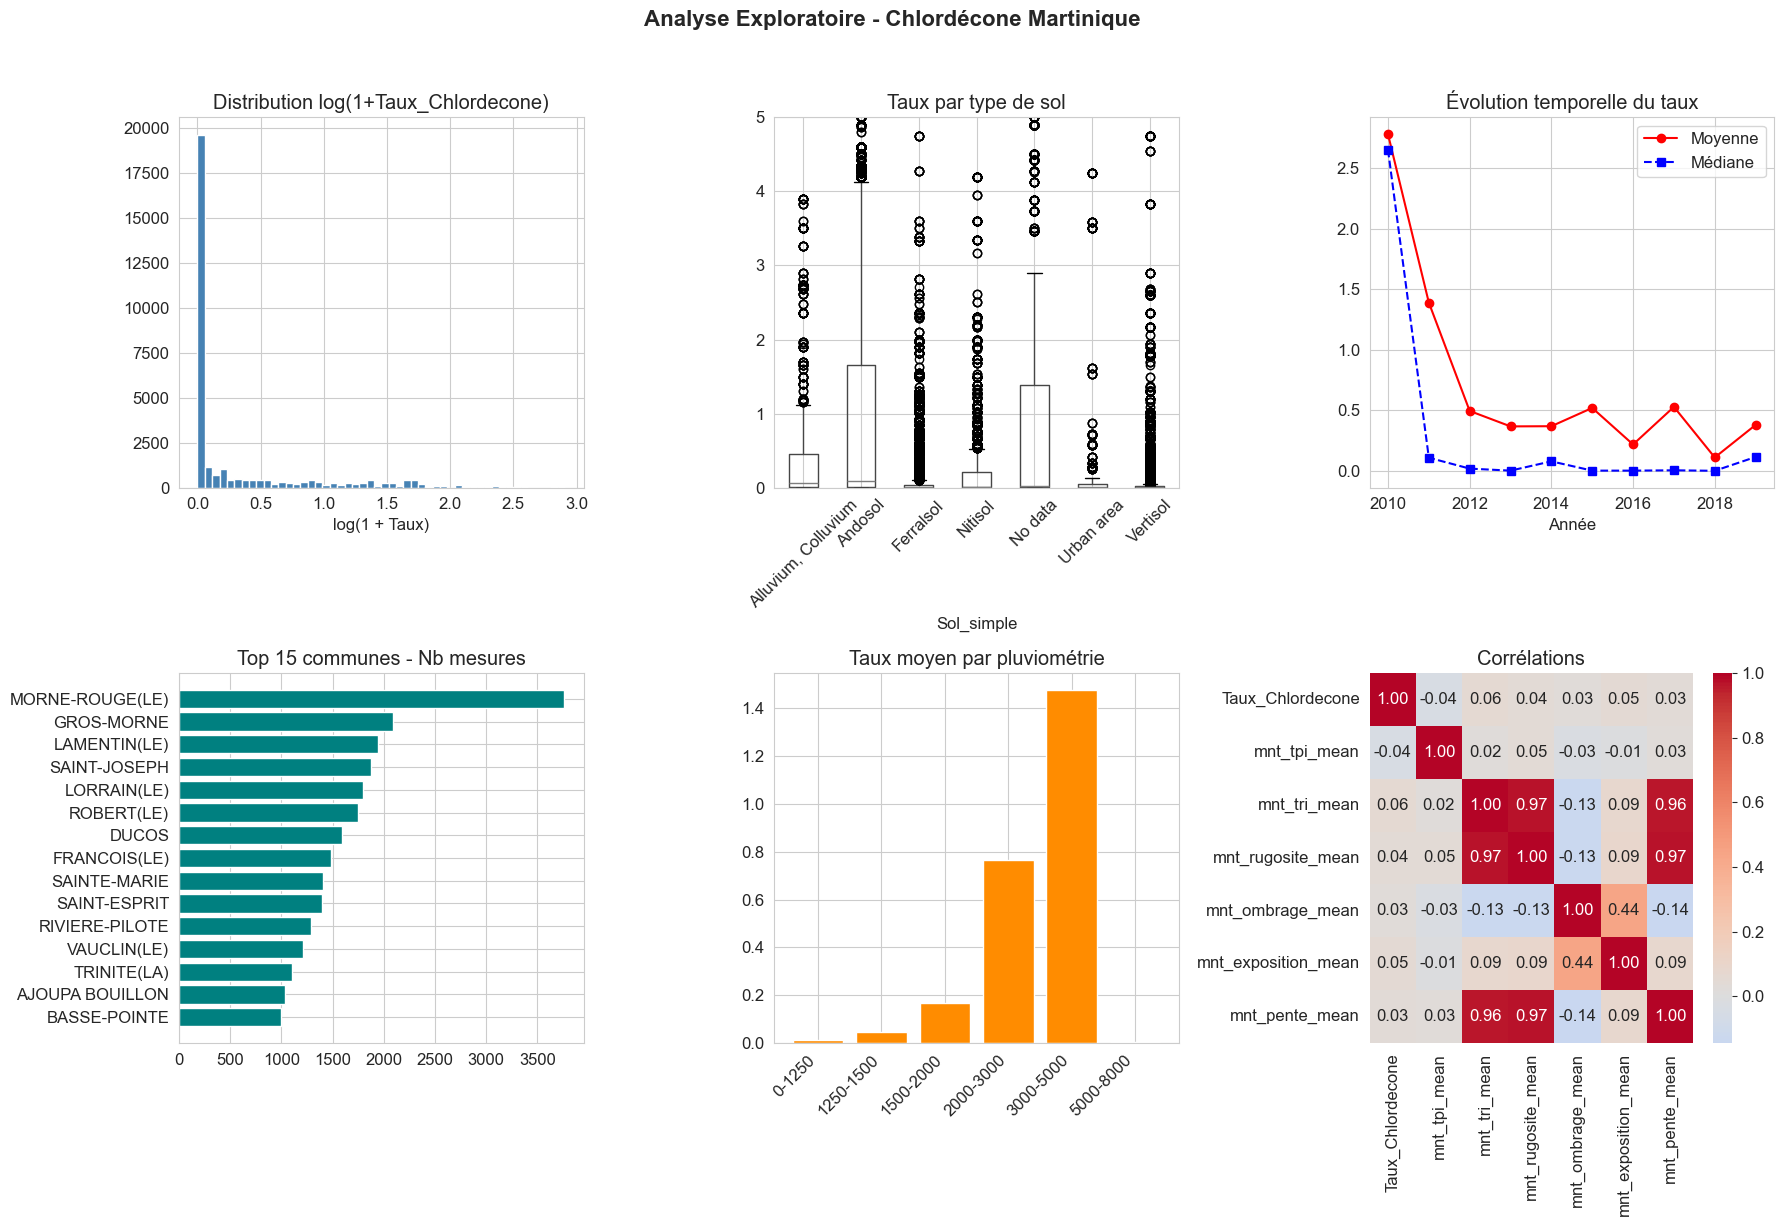

In [97]:
# --- Visualisations ---
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Distribution log
axes[0,0].hist(np.log1p(df["Taux_Chlordecone"]), bins=50, color="steelblue", edgecolor="white")
axes[0,0].set_title("Distribution log(1+Taux_Chlordecone)")
axes[0,0].set_xlabel("log(1 + Taux)")

# 2. Boxplot par sol
df.boxplot(column="Taux_Chlordecone", by="Sol_simple", ax=axes[0,1], rot=45)
axes[0,1].set_title("Taux par type de sol")
axes[0,1].set_ylim(0, 5)

# 3. Évolution temporelle
evol = df.groupby("ANNEE")["Taux_Chlordecone"].agg(["mean", "median"]).reset_index()
axes[0,2].plot(evol["ANNEE"], evol["mean"], "o-", label="Moyenne", color="red")
axes[0,2].plot(evol["ANNEE"], evol["median"], "s--", label="Médiane", color="blue")
axes[0,2].set_title("Évolution temporelle du taux")
axes[0,2].legend()
axes[0,2].set_xlabel("Année")

# 4. Nb mesures par commune
commune_counts = df["COMMU_LAB"].value_counts().head(15)
axes[1,0].barh(commune_counts.index, commune_counts.values, color="teal")
axes[1,0].set_title("Top 15 communes - Nb mesures")
axes[1,0].invert_yaxis()

# 5. Taux moyen par pluviométrie
rain_order = ["0-1250", "1250-1500", "1500-2000", "2000-3000", "3000-5000", "5000-8000"]
rain_means = df.groupby("RAIN")["Taux_Chlordecone"].mean().reindex(rain_order)
axes[1,1].bar(range(len(rain_means)), rain_means.values, color="darkorange")
axes[1,1].set_xticks(range(len(rain_means)))
axes[1,1].set_xticklabels(rain_order, rotation=45, ha="right")
axes[1,1].set_title("Taux moyen par pluviométrie")

# 6. Heatmap corrélation
num_cols = ["Taux_Chlordecone", "mnt_tpi_mean", "mnt_tri_mean", "mnt_rugosite_mean",
            "mnt_ombrage_mean", "mnt_exposition_mean", "mnt_pente_mean"]
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[1,2])
axes[1,2].set_title("Corrélations")

plt.suptitle("Analyse Exploratoire - Chlordécone Martinique", y=1.02, fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("eda_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()


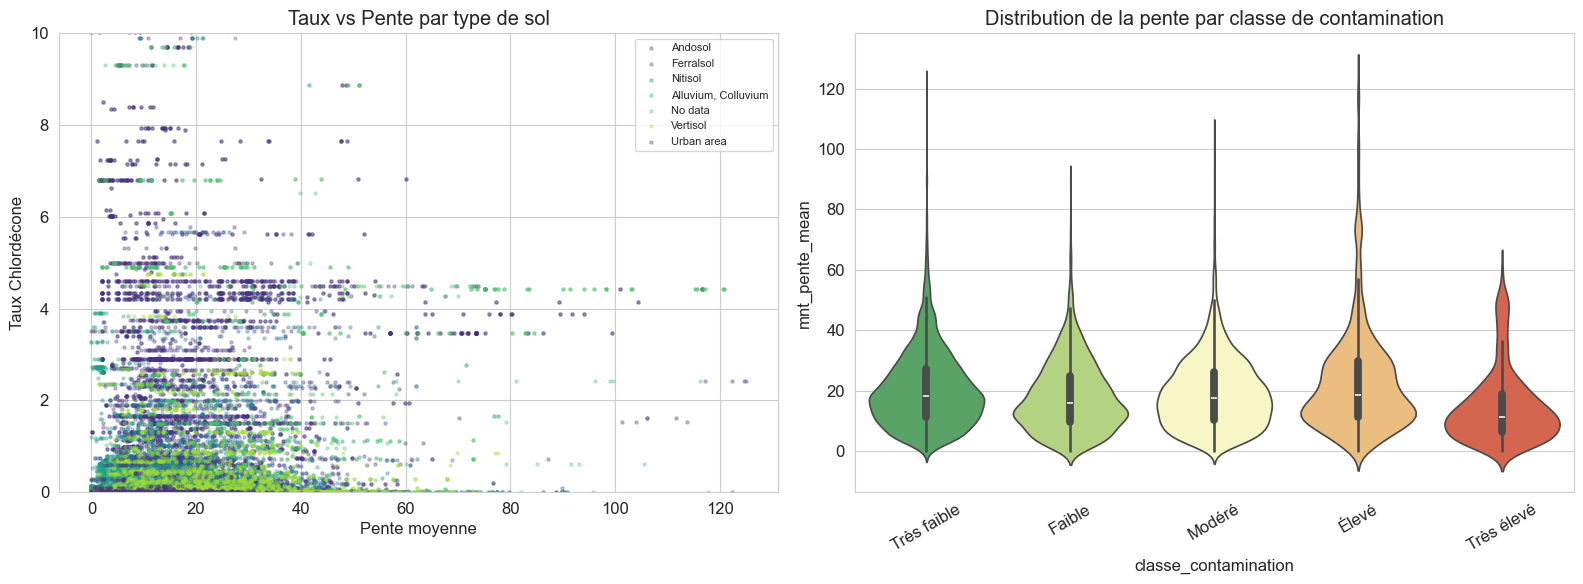

In [98]:
# --- Visualisation multivariée ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for sol in df["Sol_simple"].dropna().unique():
    mask = df["Sol_simple"] == sol
    axes[0].scatter(df.loc[mask, "mnt_pente_mean"], df.loc[mask, "Taux_Chlordecone"],
                    alpha=0.3, s=5, label=sol)
axes[0].set_xlabel("Pente moyenne")
axes[0].set_ylabel("Taux Chlordécone")
axes[0].set_ylim(0, 10)
axes[0].legend(fontsize=8)
axes[0].set_title("Taux vs Pente par type de sol")

df_plot = df.dropna(subset=["classe_contamination"])
order = ["Très faible", "Faible", "Modéré", "Élevé", "Très élevé"]
sns.violinplot(data=df_plot, x="classe_contamination", y="mnt_pente_mean",
               order=order, ax=axes[1], palette="RdYlGn_r")
axes[1].set_title("Distribution de la pente par classe de contamination")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("multivarie.png", dpi=150, bbox_inches="tight")
plt.show()


## 10. ACP — Analyse en Composantes Principales


In [99]:
# --- Préparation ACP ---
acp_cols = ["Taux_Chlordecone", "mnt_tpi_mean", "mnt_tri_mean",
            "mnt_rugosite_mean", "mnt_ombrage_mean", "mnt_exposition_mean", "mnt_pente_mean"]

df_acp = df[acp_cols].dropna()
print("Données pour ACP :", df_acp.shape)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_acp)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

print()
print("Variance expliquée par composante :")
for i, (var, cum) in enumerate(zip(pca.explained_variance_ratio_, np.cumsum(pca.explained_variance_ratio_))):
    print("  PC{} : {:.2%}  (cumulée : {:.2%})".format(i+1, var, cum))


Données pour ACP : (31126, 7)

Variance expliquée par composante :
  PC1 : 42.49%  (cumulée : 42.49%)
  PC2 : 20.68%  (cumulée : 63.16%)
  PC3 : 14.76%  (cumulée : 77.92%)
  PC4 : 13.61%  (cumulée : 91.53%)
  PC5 : 7.56%  (cumulée : 99.09%)
  PC6 : 0.52%  (cumulée : 99.62%)
  PC7 : 0.38%  (cumulée : 100.00%)


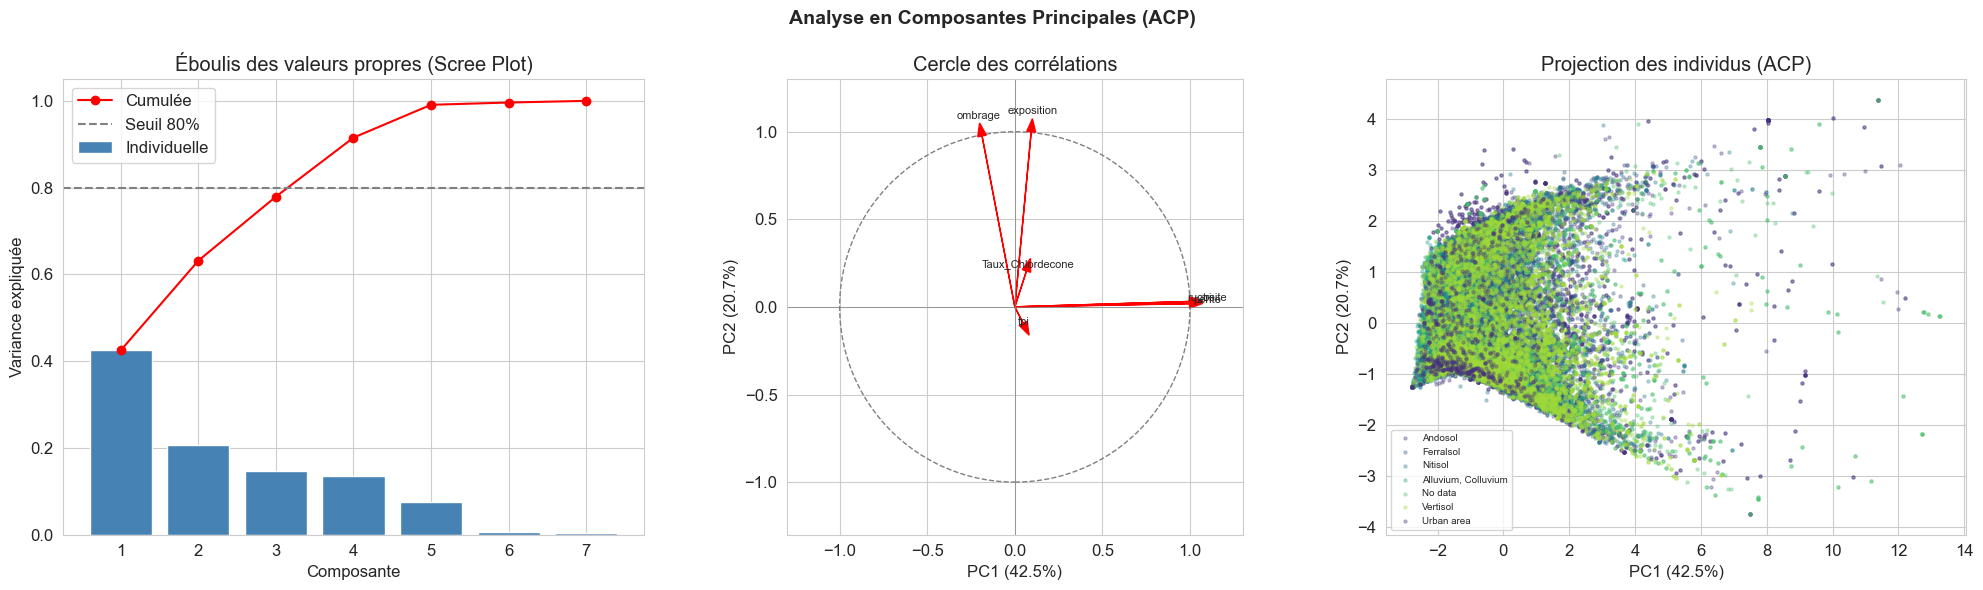

In [100]:
# --- Visualisation ACP ---
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Scree plot
axes[0].bar(range(1, len(pca.explained_variance_ratio_)+1), pca.explained_variance_ratio_,
            color="steelblue", label="Individuelle")
axes[0].plot(range(1, len(pca.explained_variance_ratio_)+1),
             np.cumsum(pca.explained_variance_ratio_), "ro-", label="Cumulée")
axes[0].axhline(y=0.8, color="gray", linestyle="--", label="Seuil 80%")
axes[0].set_xlabel("Composante")
axes[0].set_ylabel("Variance expliquée")
axes[0].set_title("Éboulis des valeurs propres (Scree Plot)")
axes[0].legend()

# 2. Cercle des corrélations
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
circle = plt.Circle((0, 0), 1, fill=False, color="gray", linestyle="--")
axes[1].add_patch(circle)
max0 = max(abs(loadings[:, 0]))
max1 = max(abs(loadings[:, 1]))
for i, var in enumerate(acp_cols):
    x_val = loadings[i, 0] / max0
    y_val = loadings[i, 1] / max1
    axes[1].arrow(0, 0, x_val, y_val, head_width=0.05, color="red")
    label = var.replace("mnt_", "").replace("_mean", "")
    axes[1].text(x_val * 1.1, y_val * 1.1, label, fontsize=8, ha="center")
axes[1].set_xlim(-1.3, 1.3)
axes[1].set_ylim(-1.3, 1.3)
axes[1].axhline(0, color="gray", lw=0.5)
axes[1].axvline(0, color="gray", lw=0.5)
axes[1].set_xlabel("PC1 ({:.1%})".format(pca.explained_variance_ratio_[0]))
axes[1].set_ylabel("PC2 ({:.1%})".format(pca.explained_variance_ratio_[1]))
axes[1].set_title("Cercle des corrélations")
axes[1].set_aspect("equal")

# 3. Projection des individus
df_proj = df.loc[df_acp.index].copy()
df_proj["PC1"] = X_pca[:, 0]
df_proj["PC2"] = X_pca[:, 1]
for sol in df_proj["Sol_simple"].dropna().unique():
    mask = df_proj["Sol_simple"] == sol
    axes[2].scatter(df_proj.loc[mask, "PC1"], df_proj.loc[mask, "PC2"],
                    alpha=0.3, s=5, label=sol)
axes[2].set_xlabel("PC1 ({:.1%})".format(pca.explained_variance_ratio_[0]))
axes[2].set_ylabel("PC2 ({:.1%})".format(pca.explained_variance_ratio_[1]))
axes[2].set_title("Projection des individus (ACP)")
axes[2].legend(fontsize=7)

plt.suptitle("Analyse en Composantes Principales (ACP)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("acp.png", dpi=150, bbox_inches="tight")
plt.show()


## 11. AFC — Analyse Factorielle des Correspondances


In [101]:
# --- AFC : Tableau de contingence Sol x Classe de contamination ---
df["classe_contam"] = pd.cut(
    df["Taux_Chlordecone"],
    bins=[0, 0.01, 0.1, 1, 5, 20],
    labels=["Très faible", "Faible", "Modéré", "Élevé", "Très élevé"],
    include_lowest=True
)

contingence = pd.crosstab(df["Sol_simple"].dropna(), df["classe_contam"].dropna())
print("=== Tableau de contingence Sol x Contamination ===")
print(contingence)

chi2, p_value, dof, expected = chi2_contingency(contingence)
print()
print("Test du Chi2 : chi2 = {:.2f}, p-value = {:.2e}, ddl = {}".format(chi2, p_value, dof))
if p_value < 0.05:
    print("-> Association significative")
else:
    print("-> Pas d'association significative")


=== Tableau de contingence Sol x Contamination ===
classe_contam        Très faible  Faible  Modéré  Élevé  Très élevé
Sol_simple                                                         
Alluvium, Colluvium          618     290     516    180           0
Andosol                     4298    1256    1833   3076         490
Ferralsol                   3547     603     672    331          29
Nitisol                     1678     324     772    277          12
No data                     1266     216     374    654         107
Urban area                   458     132      74     40           8
Vertisol                    5056     584     955    326           0

Test du Chi2 : chi2 = 4649.73, p-value = 0.00e+00, ddl = 24
-> Association significative


Inertie par axe :
  Axe 1 : 82.3%
  Axe 2 : 15.0%
  Axe 3 : 2.6%


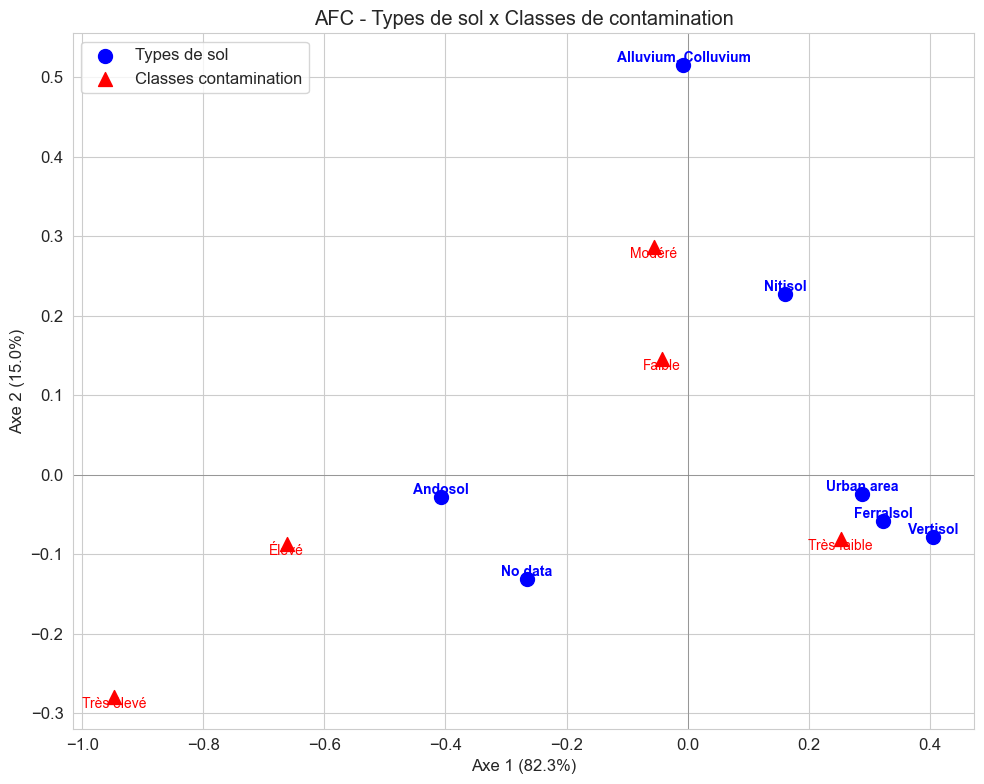

In [102]:
# --- AFC manuelle (SVD sur résidus standardisés) ---
from numpy.linalg import svd

P = contingence.values / contingence.values.sum()
r = P.sum(axis=1, keepdims=True)
c_margin = P.sum(axis=0, keepdims=True)

S = (P - r @ c_margin) / np.sqrt(r @ c_margin)
U, sigma, Vt = svd(S, full_matrices=False)

row_coords = np.diag(1/np.sqrt(r.flatten())) @ U[:, :2] * sigma[:2]
col_coords = np.diag(1/np.sqrt(c_margin.flatten())) @ Vt[:2, :].T * sigma[:2]

inertia = sigma**2
total_inertia = inertia.sum()
print("Inertie par axe :")
for i in range(min(3, len(inertia))):
    print("  Axe {} : {:.1%}".format(i+1, inertia[i]/total_inertia))

# Graphique biplot
fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(row_coords[:, 0], row_coords[:, 1], color="blue", s=100, zorder=5)
for i, lab in enumerate(contingence.index):
    ax.annotate(lab, (row_coords[i, 0], row_coords[i, 1]),
                fontsize=10, fontweight="bold", color="blue", ha="center", va="bottom")

ax.scatter(col_coords[:, 0], col_coords[:, 1], color="red", s=100, marker="^", zorder=5)
for i, lab in enumerate(contingence.columns):
    ax.annotate(str(lab), (col_coords[i, 0], col_coords[i, 1]),
                fontsize=10, color="red", ha="center", va="top")

ax.axhline(0, color="gray", lw=0.5)
ax.axvline(0, color="gray", lw=0.5)
ax.set_xlabel("Axe 1 ({:.1%})".format(inertia[0]/total_inertia))
ax.set_ylabel("Axe 2 ({:.1%})".format(inertia[1]/total_inertia))
ax.set_title("AFC - Types de sol x Classes de contamination")
ax.legend(["Types de sol", "Classes contamination"], loc="best")
plt.tight_layout()
plt.savefig("afc.png", dpi=150, bbox_inches="tight")
plt.show()


## 12. Clustering — K-means et CAH


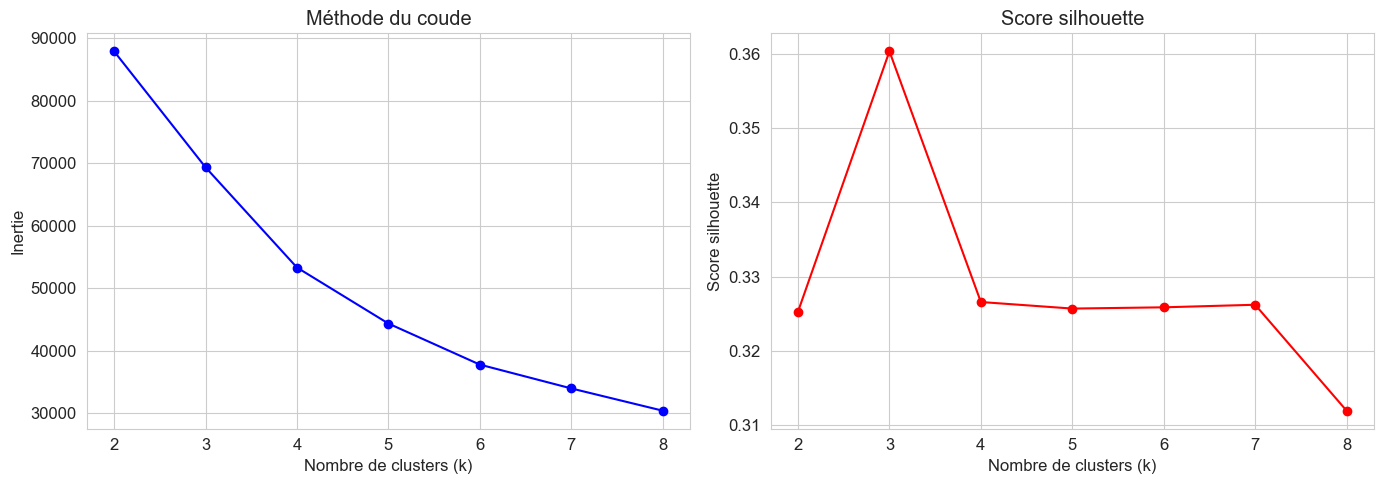

K optimal (meilleur silhouette) : 3


In [103]:
# --- K-Means ---
clust_cols = ["Taux_Chlordecone", "mnt_pente_mean", "mnt_rugosite_mean", "mnt_exposition_mean"]
df_clust = df[clust_cols].dropna()
X_clust = StandardScaler().fit_transform(df_clust)

# Méthode du coude
inertias = []
sil_scores = []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_clust)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_clust, labels, sample_size=5000))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(K_range), inertias, "bo-")
axes[0].set_xlabel("Nombre de clusters (k)")
axes[0].set_ylabel("Inertie")
axes[0].set_title("Méthode du coude")

axes[1].plot(list(K_range), sil_scores, "ro-")
axes[1].set_xlabel("Nombre de clusters (k)")
axes[1].set_ylabel("Score silhouette")
axes[1].set_title("Score silhouette")

plt.tight_layout()
plt.savefig("elbow.png", dpi=150, bbox_inches="tight")
plt.show()

k_opt = list(K_range)[np.argmax(sil_scores)]
print("K optimal (meilleur silhouette) :", k_opt)


=== Profil des clusters K-Means ===
               Taux_Chlordecone        mnt_pente_mean         \
                           mean  count           mean  count   
cluster_kmeans                                                 
0.0                       0.238  20008         13.727  20008   
1.0                       0.433   8607         36.391   8607   
2.0                       4.891   2511         17.086   2511   

               mnt_rugosite_mean        mnt_exposition_mean         
                            mean  count                mean  count  
cluster_kmeans                                                      
0.0                        9.275  20008             161.872  20008  
1.0                       23.751   8607             183.150   8607  
2.0                       11.315   2511             191.803   2511  


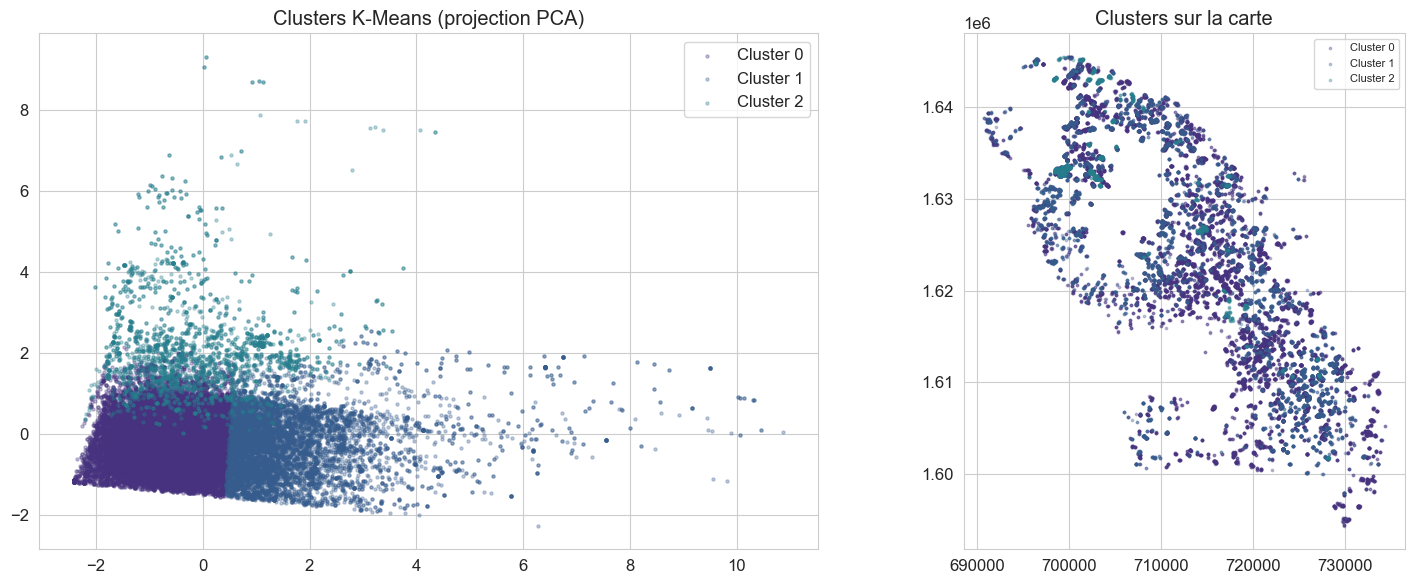

In [104]:
# --- K-Means avec k optimal ---
km_final = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
df.loc[df_clust.index, "cluster_kmeans"] = km_final.fit_predict(X_clust)

print("=== Profil des clusters K-Means ===")
profil_km = df.groupby("cluster_kmeans")[clust_cols].agg(["mean", "count"]).round(3)
print(profil_km)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

df_clust_pca = PCA(n_components=2).fit_transform(X_clust)
for cl in range(k_opt):
    mask = km_final.labels_ == cl
    axes[0].scatter(df_clust_pca[mask, 0], df_clust_pca[mask, 1],
                    alpha=0.3, s=5, label="Cluster {}".format(cl))
axes[0].set_title("Clusters K-Means (projection PCA)")
axes[0].legend()

df_mapped = df.loc[df_clust.index]
for cl in range(k_opt):
    mask = df_mapped["cluster_kmeans"] == cl
    axes[1].scatter(df_mapped.loc[mask, "X"], df_mapped.loc[mask, "Y"],
                    alpha=0.3, s=3, label="Cluster {}".format(cl))
axes[1].set_title("Clusters sur la carte")
axes[1].set_aspect("equal")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig("kmeans.png", dpi=150, bbox_inches="tight")
plt.show()


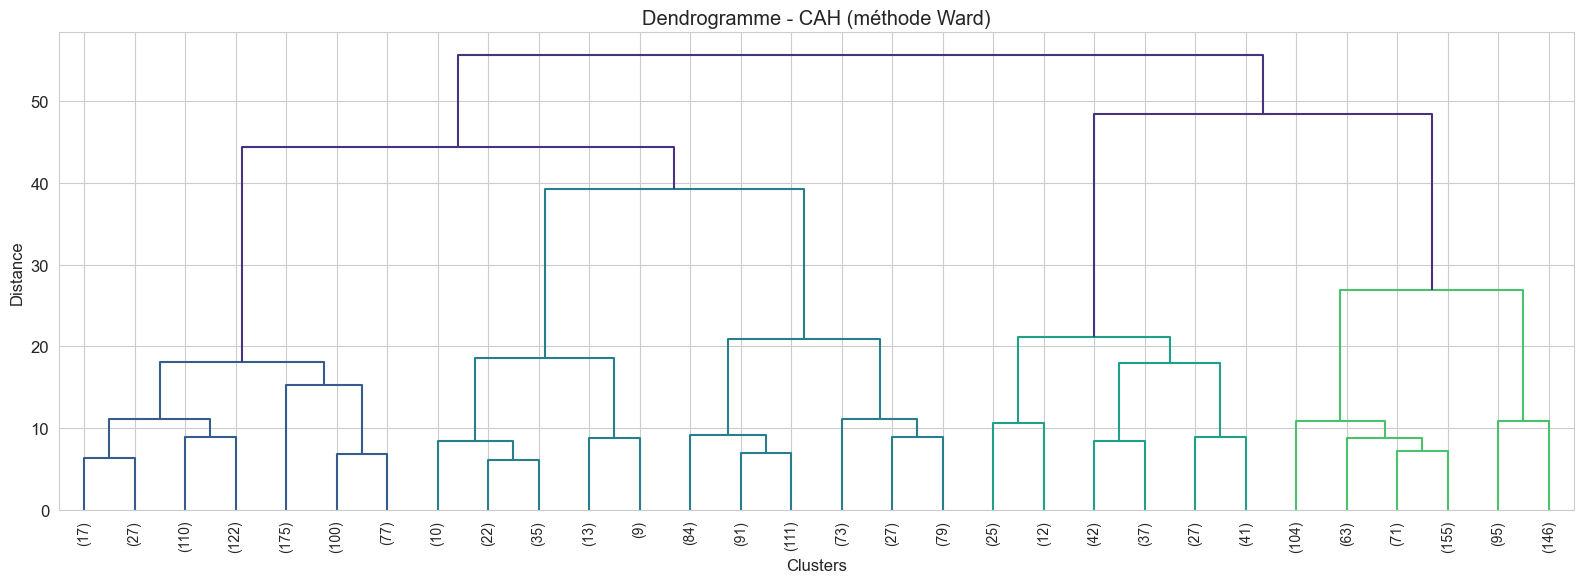

CAH - Distribution des clusters : {1: np.int64(634), 3: np.int64(628), 0: np.int64(554), 2: np.int64(184)}


In [105]:
# --- CAH ---
np.random.seed(42)
sample_idx = np.random.choice(len(X_clust), size=min(2000, len(X_clust)), replace=False)
X_sample = X_clust[sample_idx]

Z = linkage(X_sample, method="ward")

fig, ax = plt.subplots(figsize=(16, 6))
dendrogram(Z, truncate_mode="lastp", p=30, leaf_rotation=90, ax=ax,
           color_threshold=Z[-3, 2])
ax.set_title("Dendrogramme - CAH (méthode Ward)")
ax.set_xlabel("Clusters")
ax.set_ylabel("Distance")
plt.tight_layout()
plt.savefig("dendrogramme.png", dpi=150, bbox_inches="tight")
plt.show()

cah = AgglomerativeClustering(n_clusters=4)
labels_cah = cah.fit_predict(X_sample)
print("CAH - Distribution des clusters :", dict(pd.Series(labels_cah).value_counts()))


## 13. KNN — Classification supervisée


Meilleur k : 1 (accuracy = 66.44%)


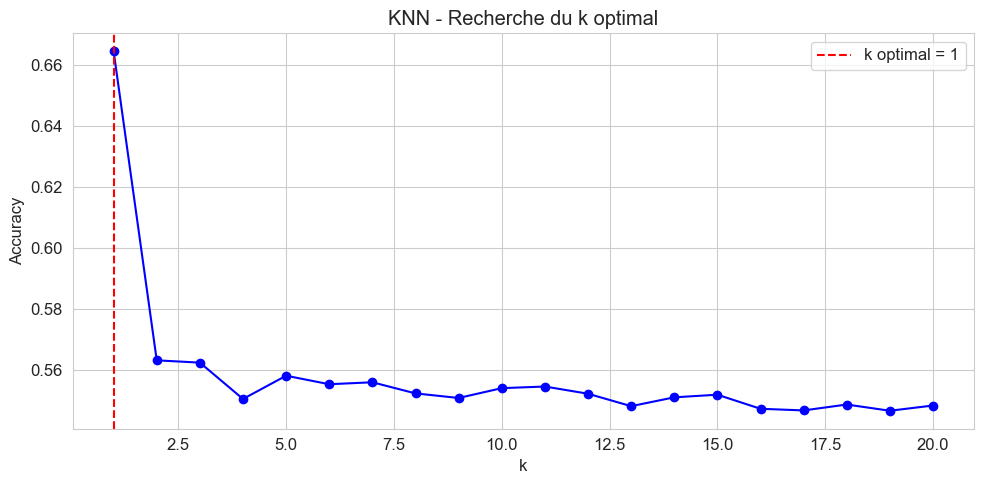

In [106]:
# --- KNN pour prédire la classe de contamination ---
df_knn = df[["mnt_pente_mean", "mnt_rugosite_mean", "mnt_exposition_mean",
             "mnt_ombrage_mean", "mnt_tpi_mean", "mnt_tri_mean",
             "classe_contamination"]].dropna()

X_knn = df_knn.drop("classe_contamination", axis=1)
y_knn = df_knn["classe_contamination"]

X_train, X_test, y_train, y_test = train_test_split(X_knn, y_knn, test_size=0.3, random_state=42)

scaler_knn = StandardScaler()
X_train_s = scaler_knn.fit_transform(X_train)
X_test_s = scaler_knn.transform(X_test)

scores = []
for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_s, y_train)
    scores.append(knn.score(X_test_s, y_test))

best_k = np.argmax(scores) + 1
print("Meilleur k : {} (accuracy = {:.2%})".format(best_k, max(scores)))

plt.figure(figsize=(10, 5))
plt.plot(range(1, 21), scores, "bo-")
plt.axvline(best_k, color="red", linestyle="--", label="k optimal = {}".format(best_k))
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.title("KNN - Recherche du k optimal")
plt.legend()
plt.tight_layout()
plt.savefig("knn_k_optimal.png", dpi=150, bbox_inches="tight")
plt.show()


=== Rapport de classification KNN ===
              precision    recall  f1-score   support

      Faible       0.50      0.49      0.49      1049
      Modéré       0.54      0.53      0.54      1589
 Très faible       0.75      0.75      0.75      5015
  Très élevé       0.63      0.61      0.62       197
       Élevé       0.62      0.64      0.63      1488

    accuracy                           0.66      9338
   macro avg       0.61      0.61      0.61      9338
weighted avg       0.66      0.66      0.66      9338



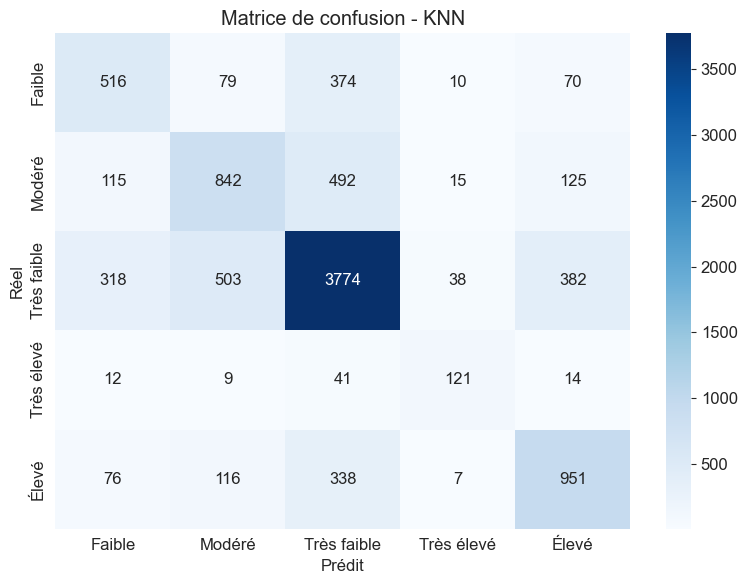

In [107]:
# --- Modèle KNN final ---
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train_s, y_train)
y_pred = knn_final.predict(X_test_s)

print("=== Rapport de classification KNN ===")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=knn_final.classes_, yticklabels=knn_final.classes_)
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.title("Matrice de confusion - KNN")
plt.tight_layout()
plt.savefig("knn_confusion.png", dpi=150, bbox_inches="tight")
plt.show()


## 14. Tests statistiques et inférence


In [108]:
# --- Tests statistiques ---
print("=" * 60)
print("TESTS STATISTIQUES")
print("=" * 60)

# 1. ANOVA
groups_sol = [g["Taux_Chlordecone"].values for _, g in df.groupby("Sol_simple") if len(g) > 30]
f_stat, p_val = f_oneway(*groups_sol)
print()
print("1. ANOVA - Taux_CLD ~ Sol_simple")
print("   F = {:.2f}, p = {:.2e}".format(f_stat, p_val))
print("   ->", "Différence significative" if p_val < 0.05 else "Pas de différence")

# 2. Chi2
ct = pd.crosstab(df["Sol_simple"].dropna(), df["detection"])
chi2_val, p_chi, dof_chi, _ = chi2_contingency(ct)
print()
print("2. Test du Chi2 - Sol x Détection")
print("   chi2 = {:.2f}, p = {:.2e}, ddl = {}".format(chi2_val, p_chi, dof_chi))
print("   ->", "Association significative" if p_chi < 0.05 else "Pas d'association")

# 3. Spearman
valid_mask = df["Taux_Chlordecone"].notna() & df["mnt_pente_mean"].notna()
rho, p_spear = spearmanr(df.loc[valid_mask, "Taux_Chlordecone"], df.loc[valid_mask, "mnt_pente_mean"])
print()
print("3. Corrélation de Spearman - Taux_CLD vs Pente")
print("   rho = {:.4f}, p = {:.2e}".format(rho, p_spear))

# 4. Kruskal-Wallis
from scipy.stats import kruskal
groups_rain = [g["Taux_Chlordecone"].values for _, g in df.groupby("RAIN")]
h_stat, p_kw = kruskal(*groups_rain)
print()
print("4. Kruskal-Wallis - Taux_CLD ~ Pluviométrie")
print("   H = {:.2f}, p = {:.2e}".format(h_stat, p_kw))
print("   ->", "Différence significative" if p_kw < 0.05 else "Pas de différence")

# 5. Shapiro-Wilk
from scipy.stats import shapiro
sample_taux = df["Taux_Chlordecone"].sample(1000, random_state=42)
w_stat, p_shapiro = shapiro(sample_taux)
print()
print("5. Test de Shapiro-Wilk (normalité, n=1000)")
print("   W = {:.4f}, p = {:.2e}".format(w_stat, p_shapiro))
print("   ->", "Distribution non normale" if p_shapiro < 0.05 else "Distribution normale")


TESTS STATISTIQUES

1. ANOVA - Taux_CLD ~ Sol_simple
   F = 582.36, p = 0.00e+00
   -> Différence significative

2. Test du Chi2 - Sol x Détection
   chi2 = 2333.42, p = 0.00e+00, ddl = 6
   -> Association significative

3. Corrélation de Spearman - Taux_CLD vs Pente
   rho = -0.0486, p = 9.51e-18

4. Kruskal-Wallis - Taux_CLD ~ Pluviométrie
   H = 3252.77, p = 0.00e+00
   -> Différence significative

5. Test de Shapiro-Wilk (normalité, n=1000)
   W = 0.5072, p = 3.84e-46
   -> Distribution non normale


## 15. Aide à la décision — Synthèse et recommandations


In [109]:
# --- Profil des territoires ---
print("=" * 70)
print("SYNTHÈSE - PROFILS DE TERRITOIRES")
print("=" * 70)

profil_commune = df.groupby("COMMU_LAB").agg(
    taux_moyen=("Taux_Chlordecone", "mean"),
    taux_median=("Taux_Chlordecone", "median"),
    pct_forte_contam=("Taux_Chlordecone", lambda x: (x > 1).mean() * 100),
    nb_mesures=("ID", "count"),
    pente_moy=("mnt_pente_mean", "mean"),
    sol_dominant=("Sol_simple", lambda x: x.mode().iloc[0] if not x.mode().empty else "NA")
).sort_values("taux_moyen", ascending=False)

print()
print("Top 10 des communes les plus contaminées :")
print(profil_commune.head(10).to_string())
print()
print("Communes les moins contaminées :")
print(profil_commune.tail(5).to_string())


SYNTHÈSE - PROFILS DE TERRITOIRES

Top 10 des communes les plus contaminées :
                 taux_moyen  taux_median  pct_forte_contam  nb_mesures  pente_moy sol_dominant
COMMU_LAB                                                                                     
MORNE-ROUGE(LE)    2.772254       2.5640         62.662769        3763  21.317076      Andosol
GRAND'RIVIERE      1.839945       0.3363         36.800000         125  42.366183      No data
MACOUBA            1.696628       1.5000         65.042980         698  20.760069      Andosol
BASSE-POINTE       1.381041       0.0900         33.770161         992  16.138633      Andosol
TRINITE(LA)        0.684156       0.0600         28.610354        1101  21.639451      Andosol
MARIGOT(LE)        0.626666       0.1630         30.303030         495  22.017745      Nitisol
LORRAIN(LE)        0.581513       0.1970         12.006670        1799  23.435791      Andosol
SAINT-PIERRE       0.561331       0.0053         16.519174         

ZONES CRITIQUES (>20% des parcelles fortement contaminées) :
6 communes identifiées
  - MORNE-ROUGE(LE): 62.7% contaminées, taux moyen = 2.772 mg/kg, sol = Andosol
  - GRAND'RIVIERE: 36.8% contaminées, taux moyen = 1.840 mg/kg, sol = No data
  - MACOUBA: 65.0% contaminées, taux moyen = 1.697 mg/kg, sol = Andosol
  - BASSE-POINTE: 33.8% contaminées, taux moyen = 1.381 mg/kg, sol = Andosol
  - TRINITE(LA): 28.6% contaminées, taux moyen = 0.684 mg/kg, sol = Andosol
  - MARIGOT(LE): 30.3% contaminées, taux moyen = 0.627 mg/kg, sol = Nitisol


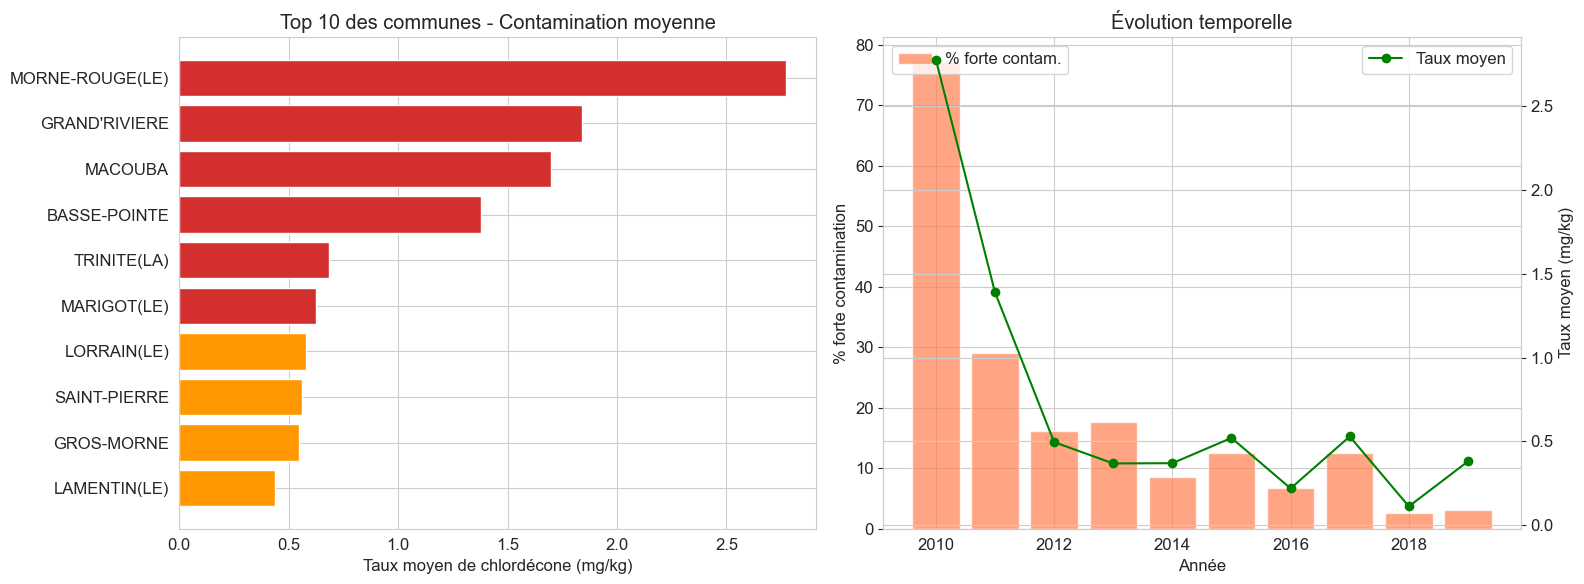

In [110]:
# --- Zones à risque ---
zones_critiques = profil_commune[profil_commune["pct_forte_contam"] > 20]
print("ZONES CRITIQUES (>20% des parcelles fortement contaminées) :")
print("{} communes identifiées".format(len(zones_critiques)))
for commune, row in zones_critiques.iterrows():
    print("  - {}: {:.1f}% contaminées, taux moyen = {:.3f} mg/kg, sol = {}".format(
        commune, row["pct_forte_contam"], row["taux_moyen"], row["sol_dominant"]))

# Visualisation finale
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top10 = profil_commune.head(10)
colors_risk = ["#d32f2f" if x > 20 else "#ff9800" if x > 10 else "#4caf50" for x in top10["pct_forte_contam"]]
axes[0].barh(top10.index, top10["taux_moyen"], color=colors_risk)
axes[0].set_xlabel("Taux moyen de chlordécone (mg/kg)")
axes[0].set_title("Top 10 des communes - Contamination moyenne")
axes[0].invert_yaxis()

evol_annuelle = df.groupby("ANNEE").agg(
    taux_moyen=("Taux_Chlordecone", "mean"),
    pct_forte=("Taux_Chlordecone", lambda x: (x > 1).mean() * 100)
).reset_index()
axes[1].bar(evol_annuelle["ANNEE"], evol_annuelle["pct_forte"], color="coral", alpha=0.7, label="% forte contam.")
ax2 = axes[1].twinx()
ax2.plot(evol_annuelle["ANNEE"], evol_annuelle["taux_moyen"], "go-", label="Taux moyen")
axes[1].set_xlabel("Année")
axes[1].set_ylabel("% forte contamination")
ax2.set_ylabel("Taux moyen (mg/kg)")
axes[1].set_title("Évolution temporelle")
axes[1].legend(loc="upper left")
ax2.legend(loc="upper right")

plt.tight_layout()
plt.savefig("aide_decision.png", dpi=150, bbox_inches="tight")
plt.show()


In [111]:
# --- RECOMMANDATIONS FINALES ---
print()
print("=" * 70)
print("RECOMMANDATIONS - AIDE À LA DÉCISION PUBLIQUE")
print("=" * 70)

recommandations = """
RÉSULTATS CLÉS :

1. CONTAMINATION HÉTÉROGÈNE
   - Le taux de chlordécone varie fortement entre communes.
   - La distribution est très asymétrique (médiane << moyenne),
     indiquant que quelques parcelles concentrent la pollution.

2. FACTEURS DE RISQUE IDENTIFIÉS
   - Type de sol : les Andosols et Nitisols retiennent
     davantage la chlordécone (ANOVA significative).
   - Historique bananier : les parcelles anciennement
     cultivées en banane sont significativement plus contaminées.
   - Pluviométrie : les zones à forte pluviométrie montrent
     des taux plus élevés (Kruskal-Wallis significatif).

3. PROFILS TERRITORIAUX (CLUSTERING)
   - Le clustering K-Means révèle des profils distincts :
     zones à risque élevé (forte contamination + sol rétenteur)
     vs zones à faible risque.

4. RECOMMANDATIONS
   - Prioriser la surveillance sur les communes identifiées
     comme zones critiques.
   - Adapter les pratiques agricoles selon le type de sol.
   - Renforcer le suivi des Andosols en zone de forte pluviométrie.
   - Poursuivre la collecte de données (58% de NaN sur histoBanane).
"""
print(recommandations)
print()
print("PROJET TERMINÉ - Analyse et Ingénierie des données de la chlordécone")



RECOMMANDATIONS - AIDE À LA DÉCISION PUBLIQUE

RÉSULTATS CLÉS :

1. CONTAMINATION HÉTÉROGÈNE
   - Le taux de chlordécone varie fortement entre communes.
   - La distribution est très asymétrique (médiane << moyenne),
     indiquant que quelques parcelles concentrent la pollution.

2. FACTEURS DE RISQUE IDENTIFIÉS
   - Type de sol : les Andosols et Nitisols retiennent
     davantage la chlordécone (ANOVA significative).
   - Historique bananier : les parcelles anciennement
     cultivées en banane sont significativement plus contaminées.
   - Pluviométrie : les zones à forte pluviométrie montrent
     des taux plus élevés (Kruskal-Wallis significatif).

3. PROFILS TERRITORIAUX (CLUSTERING)
   - Le clustering K-Means révèle des profils distincts :
     zones à risque élevé (forte contamination + sol rétenteur)
     vs zones à faible risque.

4. RECOMMANDATIONS
   - Prioriser la surveillance sur les communes identifiées
     comme zones critiques.
   - Adapter les pratiques agricoles sel